# Notebook 21 — Hidden-Event Discovery and Signal Synthesis

Notebook 21 implements the empirical versions of Linus’s Exercises 6 and 7. Exercise 6 identifies abnormal realised and implied volatility responses that may represent hidden events or cross-channel dislocations. Exercise 7 asks whether those newly identified states contain exploratory forward information that may later support an application.

N21 does not refit flexible models, re-estimate causal structure, re-estimate known-event weights, or construct the trading strategy itself. Those upstream tasks are frozen in N16–N20. This notebook consumes N20’s ordinary, event-unaware response ratios.


## 21.1 Purpose and frozen contracts

The primary detector uses event-unaware N20 ordinary-response ratios. It does not refit models, tune on TEST, or use scheduled-event or MoF dates while detecting states.


In [34]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'Data').is_dir():
    PROJECT_DIR = PROJECT_DIR / 'CODEWORK' / "Linus' Task Re-Do"
PROCESSED = PROJECT_DIR / 'Data' / 'processed'
FIGURES = PROJECT_DIR / 'figures'
FIGURES.mkdir(exist_ok=True)

FLEXIBLE_MODELS = ['RF', 'GB', 'MLP', 'TRANSFORMER']
PRIMARY_FAMILIES = ['FOMC', 'US Employment', 'US CPI', 'BoJ', 'JPY National CPI', 'JPY GDP']
MIN_MODEL_SUPPORT = 3
PRIMARY_ALPHA = 0.05
SENSITIVITY_ALPHAS = (0.10, 0.05, 0.01)
BLOCK_LENGTH = 5
BOOTSTRAP_REPS = 5_000
BOOTSTRAP_SEED = 21


## 21.2 N20 input loading and audits

N20's admissible ordinary background and canonical ordinary response ratio are authoritative. All four non-parametric models exist: RF, GB, MLP and Transformer.


In [35]:
panel = pd.read_csv(PROCESSED / '16_empirical_analysis_panel.csv', parse_dates=['model_day']).sort_values('model_day').reset_index(drop=True)
ratios = pd.read_csv(PROCESSED / '20_api_ordinary_response_ratios.csv', parse_dates=['model_day', 'target_model_day'])
event_mapping = pd.read_csv(PROCESSED / '18_target_specific_event_mapping.csv', parse_dates=['target_model_day'])
spot_model_day = pd.read_csv(PROCESSED / 'usdjpy_daily_model_panel.csv', parse_dates=['model_day'], usecols=['model_day','within_session_log_return']).sort_values('model_day')
required = {'model_day','target_model_day','sample_split','target','model','actual','admissible_forecast','ordinary_response_ratio','equation_eligible','background_positive','ordinary_flag'}
missing = required - set(ratios.columns)
assert not missing, f'N20 ordinary-response schema missing: {sorted(missing)}'
assert set(FLEXIBLE_MODELS).issubset(ratios['model'].unique())
assert np.allclose(ratios['ordinary_response_ratio'], ratios['response_ratio'], equal_nan=True)
assert np.allclose(ratios['ordinary_response_ratio'], ratios['ordinary_response_ratio_adm'], equal_nan=True)
assert panel['model_day'].is_unique and panel['model_day'].is_monotonic_increasing
assert spot_model_day['model_day'].is_unique and spot_model_day['model_day'].is_monotonic_increasing
panel = panel.merge(spot_model_day, on='model_day', how='left', validate='one_to_one')
panel['usdjpy_model_day_return'] = pd.to_numeric(panel['within_session_log_return'], errors='coerce')
panel['abs_usdjpy_model_day_return'] = panel['usdjpy_model_day_return'].abs()
spot_q_alignment = panel['squared_return'].notna() & panel['usdjpy_model_day_return'].notna()
assert spot_q_alignment.any()
assert np.allclose(panel.loc[spot_q_alignment,'squared_return'], panel.loc[spot_q_alignment,'usdjpy_model_day_return'].pow(2), rtol=1e-12, atol=1e-15)
spot_return_provenance = 'N15 usdjpy_daily_model_panel.within_session_log_return: signed sum of within-session USD/JPY hourly log returns on the canonical [D-1 17:00 NY, D 17:00 NY) model day; N16 squared_return/Q_t is its square.'
spot_return_provenance_verified = bool(spot_q_alignment.any())
panel['R'] = pd.to_numeric(panel['realised_variance_ann_252'], errors='coerce')
panel['I'] = pd.to_numeric(panel['iv_model_var'], errors='coerce')
panel['canonical_index'] = np.arange(len(panel))
panel['previous_model_day'] = panel['model_day'].shift(1)
panel['next_model_day'] = panel['model_day'].shift(-1)
panel['previous_sample_split'] = panel['sample_split'].shift(1)
assert panel['previous_model_day'].equals(panel['model_day'].shift(1))
n20_contract_audit = pd.DataFrame([{'n20_loaded': True, 'ordinary_ratio': 'actual / admissible_forecast', 'models': ' | '.join(FLEXIBLE_MODELS), 'min_model_support': MIN_MODEL_SUPPORT, 'spot_return_provenance': spot_return_provenance}])
display(n20_contract_audit)


,n20_loaded,ordinary_ratio,models,min_model_support,spot_return_provenance
0,True,actual / admissible_forecast,RF | GB | MLP | TRANSFORMER,3,N15 usdjpy_daily_model_panel.within_session_lo...


## 21.3 Ordinary response weights and signed log weights

For $Y\in\{R,I\}$ and flexible model $m$, $\widehat F^{Y,\mathrm{adm}}_{m,t}$ is the frozen ordinary event-unaware background forecast (meaning the days where there are events are not removed from the dataset). The response weight is

$$
\omega^Y_{m,t}=\frac{Y_t}{\widehat F^{Y,\mathrm{adm}}_{m,t}}.
$$

$\omega=1$ means the observation equals its ordinary background; $\omega>1$ means it is above background; and $0<\omega<1$ means it is below background. One is a neutral multiplicative benchmark, not a significance boundary. The actual $\omega$ values are retained because they provide the direct economic response magnitude.

The detector uses the signed transform $$L^Y_{m,t}=\log\omega^Y_{m,t}.$$ Hence $\omega=1\iff L=0$, while values above and below background retain opposite signs. We do not use $|\log\omega|$: very small and very large response weights can both be unusual while representing different economic directions.


## 21.4–21.6 Positivity, $\widehat F$ versus $\widehat G$, percentiles, and empirical tails

Because $\log\omega$ requires $\omega>0$, positivity is audited before scoring. Non-positive observations, if present, are retained in the audit but are not repaired by clipping, absolute values, or arbitrary epsilons; they are simply ineligible for a log score.

$\widehat F$ is a forecast. By contrast, $\widehat G_m^{Y,\mathrm{VAL}}$ is not a forecasting model: it is the empirical CDF of eligible ordinary VALIDATION signed log weights,

$$
\widehat G_m^{Y,\mathrm{VAL}}(l)=\frac1N\sum_{j\in\mathcal V_Y}\mathbf1(L^Y_{m,j}\le l).
$$

$\mathcal V_Y$ is the ordinary validation reference set.

Using $G$ avoids colliding with the forecast notation $F$. The hat means the unknown distribution is estimated from the finite ordinary VALIDATION sample. Thus $U^Y_{m,t}=\widehat G_m^{Y,\mathrm{VAL}}(L^Y_{m,t})$ is today’s empirical percentile: $U=0.98$ means roughly 98% of reference log weights were no larger. Near one is unusually high, near zero unusually low, and near 0.5 central.

$$p^{Y,emp}_{m,t}=\min[1,2\min(U^Y_{m,t},1-U^Y_{m,t})].$$

For $U=0.99$ or $0.01$, this score is approximately 0.02, but the tail direction differs. The score answers how unusual, $U$ identifies the tail, and $\omega$ gives the multiplicative response. It is an empirical two-sided tail score, not a classical parametric p-value.


In [36]:
def bool_flag(s):
    return s.fillna(False).astype(bool) if s.dtype == bool else s.astype(str).str.strip().str.lower().isin(['true', '1'])

def empirical_cdf(values, reference):
    return np.searchsorted(reference, np.asarray(values, float), side='right') / len(reference)

def empirical_two_sided_tail(u):
    return np.minimum(1.0, 2.0 * np.minimum(u, 1.0 - u))

model_scores = ratios.loc[ratios['model'].isin(FLEXIBLE_MODELS)].copy()
model_scores['omega'] = pd.to_numeric(model_scores['ordinary_response_ratio'], errors='coerce')
model_scores['ordinary_reference'] = bool_flag(model_scores['ordinary_flag'])
model_scores['finite_omega'] = np.isfinite(model_scores['omega'])
model_scores['positive_omega'] = model_scores['finite_omega'] & model_scores['omega'].gt(0)
model_scores['log_eligible'] = model_scores['positive_omega']
model_scores['log_omega'] = np.where(model_scores['log_eligible'], np.log(model_scores['omega']), np.nan)

positivity_audit = model_scores.groupby(['sample_split','target','model'], as_index=False).agg(
    total_response_ratios=('omega','size'), finite_response_ratios=('finite_omega','sum'),
    strictly_positive_ratios=('positive_omega','sum'), zero_ratios=('omega', lambda x: int((x == 0).sum())),
    negative_ratios=('omega', lambda x: int((x < 0).sum())), log_eligible_ratios=('log_eligible','sum')
)
cdf_rows, scored_parts = [], []
for (target, model), group in model_scores.groupby(['target','model'], sort=True):
    reference = group.loc[group['sample_split'].eq('validation') & group['ordinary_reference'] & group['log_eligible'], 'log_omega'].sort_values().to_numpy(float)
    assert len(reference) > 0, f'No ordinary VALIDATION log weights for {target}/{model}'
    part = group.copy()
    eligible = part['log_eligible']
    part.loc[eligible, 'U'] = empirical_cdf(part.loc[eligible, 'log_omega'], reference)
    part.loc[eligible, 'p_emp'] = empirical_two_sided_tail(part.loc[eligible, 'U'])
    scored_parts.append(part)
    cdf_rows.append({'target': target, 'model': model, 'reference_split': 'VALIDATION_ORDINARY_ONLY', 'n_reference': len(reference), 'min_log_omega': float(reference.min()), 'max_log_omega': float(reference.max())})
model_scores = pd.concat(scored_parts, ignore_index=True)
empirical_cdf_reference_summary = pd.DataFrame(cdf_rows)
ecdf_reference_audit = model_scores.groupby(['target','model'], as_index=False).apply(lambda g: pd.Series({'split':'VALIDATION','n_validation_total':int(g['sample_split'].eq('validation').sum()),'n_validation_ordinary':int((g['sample_split'].eq('validation') & g['ordinary_reference']).sum()),'n_validation_log_eligible':int((g['sample_split'].eq('validation') & g['log_eligible']).sum()),'n_ecdf_reference':int((g['sample_split'].eq('validation') & g['ordinary_reference'] & g['log_eligible']).sum())}), include_groups=False).reset_index(drop=True)
assert not model_scores.loc[~model_scores['log_eligible'], 'log_omega'].notna().any()
display(positivity_audit)
display(empirical_cdf_reference_summary)
display(ecdf_reference_audit)


,sample_split,target,model,total_response_ratios,finite_response_ratios,strictly_positive_ratios,zero_ratios,negative_ratios,log_eligible_ratios
0,test,I,GB,1208,1208,1208,0,0,1208
1,test,I,MLP,1156,1156,1156,0,0,1156
2,test,I,RF,1208,1208,1208,0,0,1208
3,test,I,TRANSFORMER,1142,1142,1142,0,0,1142
4,test,R,GB,1169,1169,1169,0,0,1169
5,test,R,MLP,1182,1182,1182,0,0,1182
6,test,R,RF,1182,1182,1182,0,0,1182
7,test,R,TRANSFORMER,1182,1182,1182,0,0,1182
8,validation,I,GB,1209,1209,1209,0,0,1209
9,validation,I,MLP,1155,1155,1155,0,0,1155


,target,model,reference_split,n_reference,min_log_omega,max_log_omega
0,I,GB,VALIDATION_ORDINARY_ONLY,945,-2.690649,2.044556
1,I,MLP,VALIDATION_ORDINARY_ONLY,899,-1.918102,2.139603
2,I,RF,VALIDATION_ORDINARY_ONLY,945,-2.070892,2.451518
3,I,TRANSFORMER,VALIDATION_ORDINARY_ONLY,888,-1.456458,2.188744
4,R,GB,VALIDATION_ORDINARY_ONLY,907,-2.992982,1.781033
5,R,MLP,VALIDATION_ORDINARY_ONLY,919,-2.304157,3.109433
6,R,RF,VALIDATION_ORDINARY_ONLY,919,-2.570957,3.198355
7,R,TRANSFORMER,VALIDATION_ORDINARY_ONLY,919,-2.336914,3.077113


,target,model,split,n_validation_total,n_validation_ordinary,n_validation_log_eligible,n_ecdf_reference
0,I,GB,VALIDATION,1209,945,1209,945
1,I,MLP,VALIDATION,1155,899,1155,899
2,I,RF,VALIDATION,1209,945,1209,945
3,I,TRANSFORMER,VALIDATION,1143,888,1143,888
4,R,GB,VALIDATION,1168,907,1168,907
5,R,MLP,VALIDATION,1181,919,1181,919
6,R,RF,VALIDATION,1181,919,1181,919
7,R,TRANSFORMER,VALIDATION,1181,919,1181,919


## 21.7–21.9 Four-model consensus, ordinary-VALIDATION thresholds, and four states

RF, GB, MLP, and Transformer each provide a model-specific empirical tail assessment. With at least $MIN\_MODEL\_SUPPORT=3$ valid models, the consensus is

$$P_t^Y=\operatorname{median}_m p_{m,t}^{Y,emp}.$$

The median is robust to one model family and we also retain $\widetilde\omega_t^Y=\operatorname{median}_m\omega_{m,t}^Y$ and $\widetilde L_t^Y=\operatorname{median}_m L_{m,t}^Y$ for magnitude and direction. Because the median tail statistic is not assumed Uniform$(0,1)$, it receives its own ordinary-VALIDATION calibration:

$$c_Y(\alpha)=Q_{\alpha}^{\mathrm{ordinary\ VAL}}(P^Y).$$

Primary $\alpha=0.05$ and 0.10/0.01 sensitivities are fixed before TEST. Both model CDFs and consensus thresholds use ordinary VALIDATION only; all eligible TEST days are then scored blindly, and known-event labels are attached afterwards. $R_t$ is paired with $I_{t-1}$ from the immediately previous canonical model-day, not calendar date minus one day.

| R channel | Previous I channel | Primary state |
| --- | --- | --- |
| ordinary | ordinary | NONE |
| abnormal | ordinary | REALISED_ONLY |
| ordinary | abnormal | IMPLIED_ONLY |
| abnormal | abnormal | JOINT |

JOINT preserves simultaneous abnormalities that could cancel in the historical $D_t=Z_R(t)-Z_I(t-1)$ representation. Direction remains separate: signed consensus log weights label ABOVE_BACKGROUND, BELOW_BACKGROUND, or AT_BACKGROUND.


In [37]:
def direction(log_value):
    if log_value > 0: return 'ABOVE_BACKGROUND'
    if log_value < 0: return 'BELOW_BACKGROUND'
    return 'AT_BACKGROUND'

consensus_rows = []
for (day, split, target), group in model_scores.groupby(['model_day','sample_split','target'], sort=True):
    valid = group.loc[group['log_eligible'] & group['p_emp'].notna()].copy()
    if len(valid) < MIN_MODEL_SUPPORT:
        continue
    median_log = float(valid['log_omega'].median())
    signs = np.sign(valid['log_omega'])
    consensus_rows.append({'model_day': day, 'sample_split': split, 'target': target, 'ordinary_reference': bool(valid['ordinary_reference'].all()), 'n_model_support': int(len(valid)), 'consensus_tail_p': float(valid['p_emp'].median()), 'omega_consensus': float(valid['omega'].median()), 'log_omega_consensus': median_log, 'median_U': float(valid['U'].median()), 'min_U': float(valid['U'].min()), 'max_U': float(valid['U'].max()), 'above_below_agreement_count': int(max((signs > 0).sum(), (signs < 0).sum(), (signs == 0).sum())), 'direction': direction(median_log)})
consensus_scores = pd.DataFrame(consensus_rows)
assert consensus_scores['n_model_support'].ge(MIN_MODEL_SUPPORT).all()

threshold_rows = []
for target in ['R','I']:
    values = consensus_scores.loc[(consensus_scores['target'].eq(target)) & (consensus_scores['sample_split'].eq('validation')) & consensus_scores['ordinary_reference'], 'consensus_tail_p']
    assert len(values) > 0
    for alpha in SENSITIVITY_ALPHAS:
        threshold_rows.append({'target': target, 'alpha': alpha, 'threshold': float(values.quantile(alpha)), 'reference_split': 'VALIDATION_ORDINARY_ONLY', 'ordinary_reference': True, 'n_reference': int(len(values))})
consensus_tail_thresholds = pd.DataFrame(threshold_rows)
consensus_threshold_reference_audit = consensus_scores.loc[consensus_scores['sample_split'].eq('validation')].groupby('target',as_index=False).agg(n_validation_consensus_total=('model_day','size'),n_validation_consensus_ordinary=('ordinary_reference','sum'))
consensus_threshold_reference_audit['n_threshold_reference'] = consensus_threshold_reference_audit['target'].map(consensus_tail_thresholds.groupby('target')['n_reference'].first())
for alpha, label in [(0.10,'c_10'),(0.05,'c_05'),(0.01,'c_01')]: consensus_threshold_reference_audit[label] = consensus_threshold_reference_audit['target'].map(consensus_tail_thresholds.loc[consensus_tail_thresholds['alpha'].eq(alpha)].set_index('target')['threshold'])
assert consensus_tail_thresholds['reference_split'].eq('VALIDATION_ORDINARY_ONLY').all() and consensus_tail_thresholds['ordinary_reference'].all()
threshold_lookup = consensus_tail_thresholds.set_index(['target','alpha'])['threshold']

r_scores = consensus_scores.loc[consensus_scores['target'].eq('R')].rename(columns={'consensus_tail_p':'consensus_tail_p_R','omega_consensus':'omega_R_consensus','log_omega_consensus':'log_omega_R_consensus','median_U':'median_U_R','min_U':'min_U_R','max_U':'max_U_R','n_model_support':'n_models_R','direction':'R_direction','above_below_agreement_count':'R_agreement'})
i_scores = consensus_scores.loc[consensus_scores['target'].eq('I')].rename(columns={'model_day':'previous_model_day','sample_split':'previous_sample_split','consensus_tail_p':'consensus_tail_p_I_prev','omega_consensus':'omega_I_prev_consensus','log_omega_consensus':'log_omega_I_prev_consensus','median_U':'median_U_I_prev','min_U':'min_U_I_prev','max_U':'max_U_I_prev','n_model_support':'n_models_I','direction':'I_direction','above_below_agreement_count':'I_agreement'})
primary_pairs = panel[['model_day','previous_model_day','sample_split','previous_sample_split','canonical_index']].merge(r_scores.drop(columns='target'), on=['model_day','sample_split'], how='inner').merge(i_scores.drop(columns='target'), on=['previous_model_day','previous_sample_split'], how='inner')
primary_pairs = primary_pairs.loc[primary_pairs['sample_split'].eq(primary_pairs['previous_sample_split'])].copy()
primary_pairs['R_threshold_05'] = threshold_lookup.loc[('R', PRIMARY_ALPHA)]
primary_pairs['I_threshold_05'] = threshold_lookup.loc[('I', PRIMARY_ALPHA)]
primary_pairs['R_abnormal'] = primary_pairs['consensus_tail_p_R'].le(primary_pairs['R_threshold_05'])
primary_pairs['I_abnormal_prev'] = primary_pairs['consensus_tail_p_I_prev'].le(primary_pairs['I_threshold_05'])
primary_pairs['primary_state'] = np.select([primary_pairs['R_abnormal'] & ~primary_pairs['I_abnormal_prev'], ~primary_pairs['R_abnormal'] & primary_pairs['I_abnormal_prev'], primary_pairs['R_abnormal'] & primary_pairs['I_abnormal_prev']], ['REALISED_ONLY','IMPLIED_ONLY','JOINT'], default='NONE')
primary_pairs['is_candidate'] = primary_pairs['primary_state'].ne('NONE')
primary_test_scores = primary_pairs.loc[primary_pairs['sample_split'].eq('test')].copy()
display(consensus_tail_thresholds)


,target,alpha,threshold,reference_split,ordinary_reference,n_reference
0,R,0.10,0.104869,VALIDATION_ORDINARY_ONLY,True,919
1,R,0.05,0.051034,VALIDATION_ORDINARY_ONLY,True,919
2,R,0.01,0.011985,VALIDATION_ORDINARY_ONLY,True,919
3,I,0.10,0.134501,VALIDATION_ORDINARY_ONLY,True,899
4,I,0.05,0.062683,VALIDATION_ORDINARY_ONLY,True,899
5,I,0.01,0.012255,VALIDATION_ORDINARY_ONLY,True,899


## 21.10–21.15 Detect first, annotate after, episodes, and diagnostics

The detector is not told FOMC, Employment, CPI, BoJ, JPY CPI, JPY GDP, or MoF dates before classification. First `primary_state` is assigned from the frozen response reference. A candidate is any non-NONE state. Only then are target-specific known-event labels attached; a strict hidden candidate is a candidate with no canonical six-family event on the $R_t/I_{t-1}$ pair. A detected FOMC response therefore remains a genuine abnormal observation but is not labelled hidden.

Month-end is retained only as an N18-consistent calendar annotation, not as a seventh event family, calibration input, or exclusion rule. Adjacent strict candidates become one episode only when they share the same state. The peak is selected by the smallest active-channel tail score,

$$p_t^{peak}=\min\{P_R(t),P_I(t-1)\}_{\mathrm{active}},$$

with the earliest day resolving a tie. The 10%, 5%, and 1% tables are sensitivity checks, not post-TEST competing specifications. Calibration transfer reports $\Delta_Y=\widehat p_Y^{TEST}-\widehat p_Y^{VAL}$ with a five-model-day chronological moving-block interval; it is a distribution-shift diagnostic, not a reason to recalibrate TEST.


In [38]:
def family_map(target):
    subset = event_mapping.loc[event_mapping['target'].eq(target) & event_mapping['event_label'].isin(PRIMARY_FAMILIES)]
    return subset.groupby('target_model_day')['event_label'].agg(lambda x: ' | '.join(sorted(set(x)))).to_dict()

r_family_map, i_family_map = family_map('R'), family_map('I')
primary_pairs['R_event_families'] = primary_pairs['model_day'].map(r_family_map).fillna('')
primary_pairs['I_prev_event_families'] = primary_pairs['previous_model_day'].map(i_family_map).fillna('')
primary_pairs['known_primary_event_pair'] = primary_pairs['R_event_families'].ne('') | primary_pairs['I_prev_event_families'].ne('')
months = panel['model_day'].dt.to_period('M')
month_end_days = set(panel.loc[panel['model_day'].eq(panel.groupby(months)['model_day'].transform('max')), 'model_day'])
primary_pairs['is_month_end_t'] = primary_pairs['model_day'].isin(month_end_days)
primary_pairs['is_month_end_prev'] = primary_pairs['previous_model_day'].isin(month_end_days)
primary_pairs['month_end_pair'] = primary_pairs['is_month_end_t'] | primary_pairs['is_month_end_prev']
primary_pairs['strict_hidden_candidate'] = primary_pairs['is_candidate'] & ~primary_pairs['known_primary_event_pair']
primary_test_scores = primary_pairs.loc[primary_pairs['sample_split'].eq('test')].copy()
primary_all_candidate_days = primary_test_scores.loc[primary_test_scores['is_candidate']].sort_values('canonical_index').copy()
primary_candidate_days = primary_test_scores.loc[primary_test_scores['strict_hidden_candidate']].sort_values('canonical_index').copy()

def build_episodes(frame, state_col, strict_col, prefix):
    days = frame.loc[frame[strict_col]].sort_values('canonical_index').copy()
    active = np.where(days['R_abnormal'], days['consensus_tail_p_R'], np.nan)
    implied = np.where(days['I_abnormal_prev'], days['consensus_tail_p_I_prev'], np.nan)
    days['candidate_severity_tail_p'] = np.nanmin(np.column_stack([active, implied]), axis=1) if len(days) else np.array([])
    days['new_episode'] = days[state_col].ne(days[state_col].shift()) | days['canonical_index'].diff().ne(1)
    days['episode_number'] = days['new_episode'].cumsum().astype(int)
    days['hidden_episode_id'] = prefix + days['episode_number'].astype(str).str.zfill(3)
    rows = []
    for episode_id, group in days.groupby('hidden_episode_id', sort=True):
        peak = group.sort_values(['candidate_severity_tail_p','canonical_index']).iloc[0]
        rows.append({'hidden_episode_id': episode_id, 'primary_state': peak[state_col], 'start_day': group['model_day'].min(), 'end_day': group['model_day'].max(), 'peak_day': peak['model_day'], 'peak_tail_p': peak['candidate_severity_tail_p'], 'number_of_days': int(len(group))})
    return days, pd.DataFrame(rows)

primary_candidate_days, primary_hidden_episodes = build_episodes(primary_pairs.loc[primary_pairs['sample_split'].eq('test')].copy(), 'primary_state', 'strict_hidden_candidate', 'E21_PRIMARY_')
display(primary_candidate_days[['model_day','primary_state','omega_R_consensus','omega_I_prev_consensus','strict_hidden_candidate','known_primary_event_pair']])


,model_day,primary_state,omega_R_consensus,omega_I_prev_consensus,strict_hidden_candidate,known_primary_event_pair
1140,2021-11-25,REALISED_ONLY,0.090839,0.741822,True,False
1141,2021-11-26,REALISED_ONLY,7.965067,0.561113,True,False
1142,2021-11-29,IMPLIED_ONLY,1.004328,3.551621,True,False
1143,2021-11-30,REALISED_ONLY,4.440837,0.649509,True,False
1166,2021-12-31,REALISED_ONLY,0.174314,0.544105,True,False
...,...,...,...,...,...,...
2258,2026-06-23,REALISED_ONLY,0.120043,1.211080,True,False
2259,2026-06-24,REALISED_ONLY,0.118294,0.681747,True,False
2260,2026-06-25,REALISED_ONLY,0.142917,0.534920,True,False
2262,2026-06-29,REALISED_ONLY,0.086551,0.720914,True,False


### Response-weight distributions before and after known-event exclusion

The individual candidate table above shows the actual realised- and implied-channel response weights for each strict-hidden day. To summarise their overall distributions, the table below compares:

1. **All abnormal TEST candidates**: all `REALISED_ONLY`, `IMPLIED_ONLY`, and `JOINT` observations before known-event exclusion.
2. **Strict-hidden candidates**: the subset remaining after removing detector pairs coincident with the six primary scheduled-event families.

For each channel, the median and interquartile range are emphasised because response weights can be strongly skewed. The mean, minimum and maximum are retained as supplementary descriptive statistics. The fractions above and below one indicate whether responses tended to lie above or below their ordinary model background.

In [39]:
# ------------------------------------------------------------
# Descriptive distributions of candidate response weights
# ------------------------------------------------------------

def summarise_response_weights(frame, sample_label):
    """
    Summarise the consensus response-weight distributions for
    realised variance and previous-model-day implied variance.
    """
    
    rows = []

    weight_columns = {
        "Realised R_t": "omega_R_consensus",
        "Previous implied I_(t-1)": "omega_I_prev_consensus",
    }

    for channel, column in weight_columns.items():
        values = pd.to_numeric(frame[column], errors="coerce").dropna()

        rows.append({
            "sample": sample_label,
            "channel": channel,
            "n": len(values),
            "mean_omega": values.mean(),
            "median_omega": values.median(),
            "q25_omega": values.quantile(0.25),
            "q75_omega": values.quantile(0.75),
            "min_omega": values.min(),
            "max_omega": values.max(),
            "pct_below_1": 100 * (values < 1).mean(),
            "pct_above_1": 100 * (values > 1).mean(),
        })

    return pd.DataFrame(rows)


# All abnormal TEST candidates before removing the six known event families
all_candidate_summary = summarise_response_weights(
    primary_all_candidate_days,
    "All abnormal candidates"
)

# Strict-hidden candidates after known-event exclusion
strict_hidden_summary = summarise_response_weights(
    primary_candidate_days,
    "Strict-hidden candidates"
)

candidate_weight_distribution_summary = pd.concat(
    [all_candidate_summary, strict_hidden_summary],
    ignore_index=True
)

display(
    candidate_weight_distribution_summary.round({
        "mean_omega": 4,
        "median_omega": 4,
        "q25_omega": 4,
        "q75_omega": 4,
        "min_omega": 4,
        "max_omega": 4,
        "pct_below_1": 1,
        "pct_above_1": 1,
    })
)

,sample,channel,n,mean_omega,median_omega,q25_omega,q75_omega,min_omega,max_omega,pct_below_1,pct_above_1
0,All abnormal candidates,Realised R_t,209,1.8567,0.9512,0.4208,2.1150,0.0210,25.8695,54.1,45.9
1,All abnormal candidates,Previous implied I_(t-1),209,1.9108,1.6106,0.8940,2.2361,0.2246,11.8237,30.1,69.9
2,Strict-hidden candidates,Realised R_t,93,1.6648,0.7555,0.1994,2.7536,0.0866,8.9967,57.0,43.0
3,Strict-hidden candidates,Previous implied I_(t-1),93,1.2780,1.0203,0.6867,1.7272,0.2246,3.5748,49.5,50.5


This table tells us that the weight distribution is heavily right skewed.

In [40]:
# ------------------------------------------------------------
# Median response weights by abnormality state
# ------------------------------------------------------------

state_summary_rows = []

for sample_label, frame in [
    ("All abnormal candidates", primary_all_candidate_days),
    ("Strict-hidden candidates", primary_candidate_days),
]:
    for state in ["REALISED_ONLY", "IMPLIED_ONLY", "JOINT"]:
        subset = frame.loc[frame["primary_state"].eq(state)]

        if len(subset) == 0:
            continue

        state_summary_rows.append({
            "sample": sample_label,
            "primary_state": state,
            "n": len(subset),
            "median_omega_R": subset["omega_R_consensus"].median(),
            "median_omega_I_prev": subset["omega_I_prev_consensus"].median(),
        })

candidate_weight_state_summary = pd.DataFrame(state_summary_rows)

display(
    candidate_weight_state_summary.round({
        "median_omega_R": 4,
        "median_omega_I_prev": 4,
    })
)

,sample,primary_state,n,median_omega_R,median_omega_I_prev
0,All abnormal candidates,REALISED_ONLY,65,2.9220,0.8281
1,All abnormal candidates,IMPLIED_ONLY,125,0.8689,1.8971
2,All abnormal candidates,JOINT,19,2.9702,2.1073
3,Strict-hidden candidates,REALISED_ONLY,43,2.7536,0.7668
4,Strict-hidden candidates,IMPLIED_ONLY,44,0.7696,1.6505
5,Strict-hidden candidates,JOINT,6,0.1935,1.9468


### Full versus strict-hidden response-weight distributions

The histograms below compare the consensus response-weight distributions across all eligible TEST detector pairs with the corresponding distributions on strict-hidden candidate days.

The vertical reference line at

$$
\omega = 1
$$

denotes equality between the observed response and the ordinary event-unaware model background. Values above one indicate responses above background, while values below one indicate responses below background.

Because the response-weight distributions are strongly right-skewed, the horizontal axis is shown on a logarithmic scale while retaining the original response-weight units. The same binning is used within each channel so that the full TEST and strict-hidden distributions can be compared directly.

Candidate response weights are strongly skewed, particularly on the realised side, so medians and interquartile rangees are more informative than means alone.

Removing observations coincident with six primary scheduled-event families substantially reduces the upper tail of implied response weights; median implied weight falls from 1.61 to 1.19 and the maximum from 11.82 to 3.55.

State specific summaries clarify the pooled results: REALISED_ONLY obs are characterised by elevated or depressed realised responses while IMPLIED_ONLY observations primarily exhibit unusual implied responses.

The five strict-hidden JOINT episodes display a different directional pattern, with a median realised response below background and implied response above background; given the small sample, this is treated descriptively.

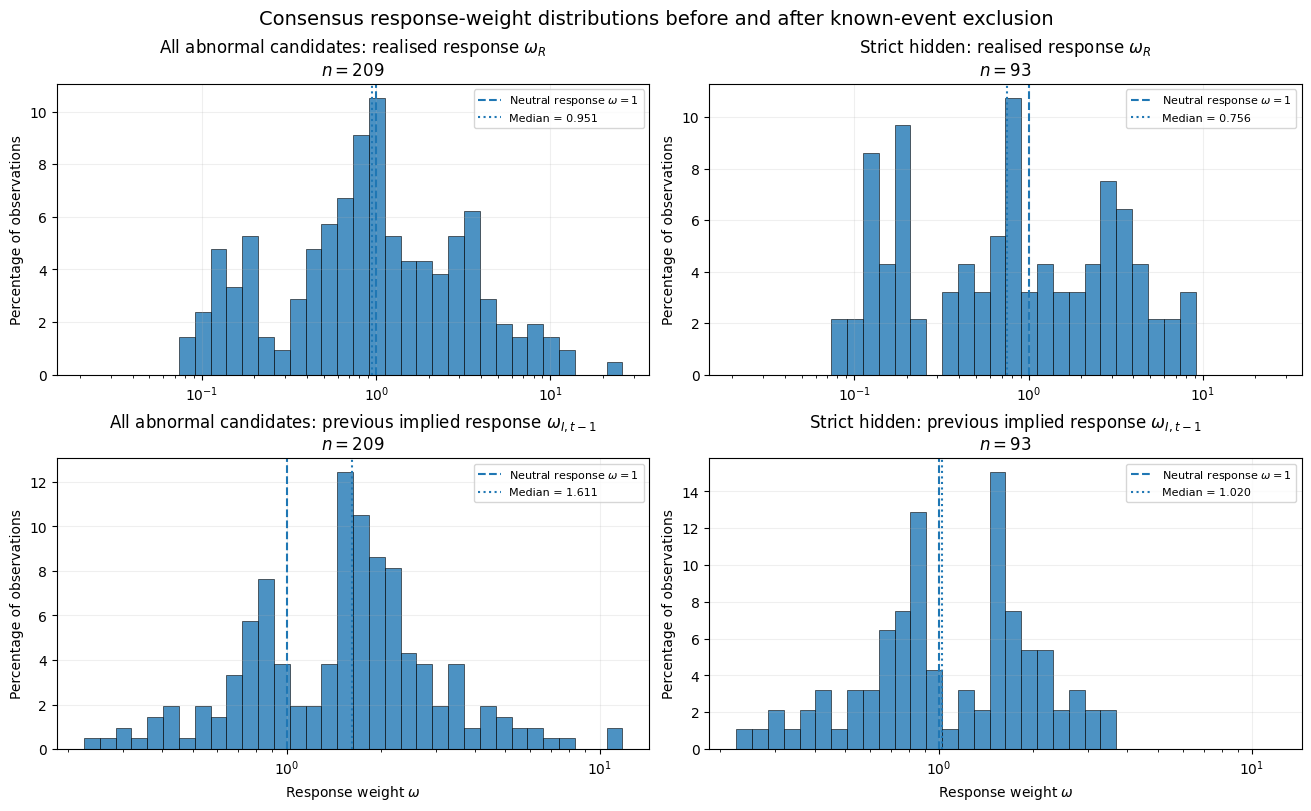

In [41]:
# ------------------------------------------------------------
# Response-weight distributions before and after
# known-event exclusion
#
# Left column:
#   All abnormal TEST candidates before excluding the six
#   known scheduled-event families (n = 209 at alpha = 0.05)
#
# Right column:
#   Strict-hidden candidates after excluding detector pairs
#   coincident with the six known event families under the earlier annotation (superseded)
# ------------------------------------------------------------


# All abnormal TEST candidates before known-event exclusion
all_candidate_weights = primary_all_candidate_days.copy()

# Strict-hidden candidates after known-event exclusion
strict_hidden_weights = primary_candidate_days.copy()


def clean_positive(series):
    """
    Keep only finite, strictly positive response weights.

    Response weights must be positive for the logarithmic x-axis.
    The earlier positivity audit has already verified that valid
    response ratios satisfy this requirement.
    """
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)

    return values[
        np.isfinite(values)
        & (values > 0)
    ]


# ------------------------------------------------------------
# Extract realised and implied consensus response weights
# ------------------------------------------------------------

# Realised response:
# omega_R = actual R_t / ordinary admissible background forecast
all_R = clean_positive(
    all_candidate_weights["omega_R_consensus"]
)

hidden_R = clean_positive(
    strict_hidden_weights["omega_R_consensus"]
)


# Previous-model-day implied response:
# omega_I_prev = actual I_(t-1) / ordinary admissible background forecast
all_I = clean_positive(
    all_candidate_weights["omega_I_prev_consensus"]
)

hidden_I = clean_positive(
    strict_hidden_weights["omega_I_prev_consensus"]
)


# ------------------------------------------------------------
# Common histogram bins within each channel
#
# Using the same bins for the left and right panels makes the
# before/after-known-event comparison directly interpretable.
#
# Log-spaced bins are used because the weight distributions
# are strongly right-skewed.
# ------------------------------------------------------------

R_min = min(all_R.min(), hidden_R.min())
R_max = max(all_R.max(), hidden_R.max())

R_bins = np.logspace(
    np.log10(R_min),
    np.log10(R_max),
    35
)


I_min = min(all_I.min(), hidden_I.min())
I_max = max(all_I.max(), hidden_I.max())

I_bins = np.logspace(
    np.log10(I_min),
    np.log10(I_max),
    35
)


# ------------------------------------------------------------
# Plotting helper
# ------------------------------------------------------------

def plot_weight_hist(ax, values, bins, title):
    """
    Plot a response-weight histogram as a percentage of the
    observations in that sample.

    omega = 1:
        actual response equals ordinary model background

    omega > 1:
        actual response is above background

    omega < 1:
        actual response is below background
    """

    # Express histogram height as percentage rather than raw count.
    # This makes samples of different sizes directly comparable.
    histogram_weights = (
        np.ones(len(values), dtype=float)
        * 100.0
        / len(values)
    )

    ax.hist(
        values,
        bins=bins,
        weights=histogram_weights,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )

    # Neutral-response reference:
    # omega = 1 means actual = ordinary forecast background.
    ax.axvline(
        1.0,
        linestyle="--",
        linewidth=1.5,
        label=r"Neutral response $\omega=1$",
    )

    # Sample median
    median_value = np.median(values)

    ax.axvline(
        median_value,
        linestyle=":",
        linewidth=1.5,
        label=fr"Median = {median_value:.3f}",
    )

    # Logarithmic x-axis keeps the raw omega units while
    # making both small and very large response weights visible.
    ax.set_xscale("log")

    ax.set_title(
        f"{title}\n"
        rf"$n={len(values)}$"
    )

    ax.set_ylabel("Percentage of observations")

    ax.grid(
        alpha=0.2
    )

    ax.legend(
        fontsize=8
    )


# ------------------------------------------------------------
# Construct the 2 x 2 figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    sharex="row",
    constrained_layout=True,
)


# ------------------------------------------------------------
# Top row: realised response weights
# ------------------------------------------------------------

# Top-left:
# all 209 abnormal TEST candidates before known-event exclusion
plot_weight_hist(
    axes[0, 0],
    all_R,
    R_bins,
    r"All abnormal candidates: realised response $\omega_R$",
)


# Top-right:
# Earlier strict-hidden annotation count (superseded by corrected timing)
plot_weight_hist(
    axes[0, 1],
    hidden_R,
    R_bins,
    r"Strict hidden: realised response $\omega_R$",
)


# ------------------------------------------------------------
# Bottom row: previous-model-day implied response weights
# ------------------------------------------------------------

# Bottom-left:
# all 209 abnormal TEST candidates before known-event exclusion
plot_weight_hist(
    axes[1, 0],
    all_I,
    I_bins,
    r"All abnormal candidates: previous implied response $\omega_{I,t-1}$",
)


# Bottom-right:
# Earlier strict-hidden annotation count (superseded by corrected timing)
plot_weight_hist(
    axes[1, 1],
    hidden_I,
    I_bins,
    r"Strict hidden: previous implied response $\omega_{I,t-1}$",
)


# x-axis labels
axes[1, 0].set_xlabel(
    r"Response weight $\omega$"
)

axes[1, 1].set_xlabel(
    r"Response weight $\omega$"
)


# Overall figure title
fig.suptitle(
    "Consensus response-weight distributions before and after known-event exclusion",
    fontsize=14,
)


plt.show()

In [42]:
sensitivity_rows = []
for alpha in SENSITIVITY_ALPHAS:
    flagged = primary_test_scores.copy()
    flagged['R_abnormal_alpha'] = flagged['consensus_tail_p_R'].le(threshold_lookup.loc[('R',alpha)])
    flagged['I_abnormal_alpha'] = flagged['consensus_tail_p_I_prev'].le(threshold_lookup.loc[('I',alpha)])
    flagged['state_alpha'] = np.select([flagged['R_abnormal_alpha'] & ~flagged['I_abnormal_alpha'], ~flagged['R_abnormal_alpha'] & flagged['I_abnormal_alpha'], flagged['R_abnormal_alpha'] & flagged['I_abnormal_alpha']], ['REALISED_ONLY','IMPLIED_ONLY','JOINT'], default='NONE')
    flagged['strict_alpha'] = flagged['state_alpha'].ne('NONE') & ~flagged['known_primary_event_pair']
    episode_input = flagged.copy()
    episode_input['primary_state'] = flagged['state_alpha']
    episode_input['strict_hidden_candidate'] = flagged['strict_alpha']
    episode_input['R_abnormal'] = flagged['R_abnormal_alpha']
    episode_input['I_abnormal_prev'] = flagged['I_abnormal_alpha']
    _, alpha_episodes = build_episodes(episode_input, 'primary_state', 'strict_hidden_candidate', f'E21_A{int(alpha*100):02d}_')
    candidates = flagged.loc[flagged['state_alpha'].ne('NONE')]
    sensitivity_rows.append({'alpha':alpha, 'R_threshold':threshold_lookup.loc[('R',alpha)], 'I_threshold':threshold_lookup.loc[('I',alpha)], 'candidate_day_count':int(len(candidates)), 'strict_hidden_candidate_day_count':int(flagged['strict_alpha'].sum()), 'realised_only_count':int(candidates['state_alpha'].eq('REALISED_ONLY').sum()), 'implied_only_count':int(candidates['state_alpha'].eq('IMPLIED_ONLY').sum()), 'joint_count':int(candidates['state_alpha'].eq('JOINT').sum()), 'strict_hidden_episode_count':int(len(alpha_episodes))})
primary_threshold_sensitivity = pd.DataFrame(sensitivity_rows)

def mbb_rate_draws(values, seed):
    values = np.asarray(values, float)
    n = len(values); starts = np.arange(n - BLOCK_LENGTH + 1)
    rng = np.random.default_rng(seed); blocks = rng.choice(starts, size=(BOOTSTRAP_REPS, int(np.ceil(n / BLOCK_LENGTH))), replace=True)
    positions = (blocks[..., None] + np.arange(BLOCK_LENGTH)).reshape(BOOTSTRAP_REPS, -1)[:, :n]
    return values[positions].mean(axis=1)

calibration_rows = []
for alpha in SENSITIVITY_ALPHAS:
    for target, column in [('R','consensus_tail_p_R'),('I','consensus_tail_p_I_prev')]:
        threshold = threshold_lookup.loc[(target,alpha)]
        validation_flags = primary_pairs.loc[primary_pairs['sample_split'].eq('validation'), column].le(threshold).to_numpy(float)
        test_flags = primary_pairs.loc[primary_pairs['sample_split'].eq('test'), column].le(threshold).to_numpy(float)
        validation_draws = mbb_rate_draws(validation_flags, BOOTSTRAP_SEED)
        test_draws = mbb_rate_draws(test_flags, BOOTSTRAP_SEED + 1)
        delta_draws = test_draws - validation_draws
        calibration_rows.append({'target':target,'alpha':alpha,'validation_abnormal_fraction':float(validation_flags.mean()),'validation_ci_low':float(np.quantile(validation_draws,.025)),'validation_ci_high':float(np.quantile(validation_draws,.975)),'test_abnormal_fraction':float(test_flags.mean()),'test_ci_low':float(np.quantile(test_draws,.025)),'test_ci_high':float(np.quantile(test_draws,.975)),'test_minus_validation':float(test_flags.mean()-validation_flags.mean()),'difference_ci_low':float(np.quantile(delta_draws,.025)),'difference_ci_high':float(np.quantile(delta_draws,.975)),'threshold':threshold,'bootstrap_method':'chronological_moving_block_length_5'})
primary_calibration_transfer = pd.DataFrame(calibration_rows)

event_rows=[]
for family in PRIMARY_FAMILIES:
    event_pairs=primary_test_scores.loc[primary_test_scores['R_event_families'].str.contains(family,regex=False) | primary_test_scores['I_prev_event_families'].str.contains(family,regex=False)]
    event_rows.append({'family':family,'n_eligible_event_pairs':int(len(event_pairs)),'n_candidate_event_pairs':int(event_pairs['is_candidate'].sum()),'candidate_rate':float(event_pairs['is_candidate'].mean()) if len(event_pairs) else np.nan,'realised_only_count':int(event_pairs['primary_state'].eq('REALISED_ONLY').sum()),'implied_only_count':int(event_pairs['primary_state'].eq('IMPLIED_ONLY').sum()),'joint_count':int(event_pairs['primary_state'].eq('JOINT').sum())})
known_event_detection_diagnostic=pd.DataFrame(event_rows)
display(primary_threshold_sensitivity)
display(primary_calibration_transfer)
display(known_event_detection_diagnostic)


,alpha,R_threshold,I_threshold,candidate_day_count,strict_hidden_candidate_day_count,realised_only_count,implied_only_count,joint_count,strict_hidden_episode_count
0,0.10,0.104869,0.134501,349,194,137,168,44,175
1,0.05,0.051034,0.062683,209,93,65,125,19,85
2,0.01,0.011985,0.012255,69,26,30,37,2,23


,target,alpha,validation_abnormal_fraction,validation_ci_low,validation_ci_high,test_abnormal_fraction,test_ci_low,test_ci_high,test_minus_validation,difference_ci_low,difference_ci_high,threshold,bootstrap_method
0,R,0.10,0.109444,0.090909,0.128861,0.159894,0.134276,0.185534,0.050450,0.017773,0.081350,0.104869,chronological_moving_block_length_5
1,I,0.10,0.100618,0.081200,0.120918,0.187279,0.164311,0.210247,0.086661,0.056635,0.117564,0.134501,chronological_moving_block_length_5
2,R,0.05,0.051192,0.038835,0.065313,0.074205,0.056537,0.090106,0.023013,0.000060,0.044209,0.051034,chronological_moving_block_length_5
3,I,0.05,0.048544,0.035305,0.062665,0.127208,0.107774,0.147527,0.078665,0.054821,0.102506,0.062683,chronological_moving_block_length_5
4,R,0.01,0.011474,0.005296,0.018535,0.028269,0.017668,0.038869,0.016795,0.003548,0.029161,0.011985,chronological_moving_block_length_5
5,I,0.01,0.005296,0.001765,0.009709,0.034452,0.024735,0.045053,0.029157,0.018556,0.040639,0.012255,chronological_moving_block_length_5


,family,n_eligible_event_pairs,n_candidate_event_pairs,candidate_rate,realised_only_count,implied_only_count,joint_count
0,FOMC,70,20,0.285714,7,10,3
1,US Employment,53,32,0.603774,5,24,3
2,US CPI,53,28,0.528302,2,22,4
3,BoJ,36,33,0.916667,0,28,5
4,JPY National CPI,54,16,0.296296,8,6,2
5,JPY GDP,36,3,0.083333,0,3,0


## 21.16–21.19 Sparse chronology, maps, MoF validation, and circular shifts

The headline sparse timeline intentionally shows only strict-hidden episode peaks, their states, official MoF intervention dates, and the six-family post-detection event rug. It omits ordinary TEST observations so that clustering and proximity can be read directly; the rug provides scheduled-event context without hundreds of full-height lines.

The abnormality map answers how empirically unusual each realised/implied pair is: the frozen tail thresholds partition NONE, REALISED_ONLY, IMPLIED_ONLY, and JOINT. The signed log-weight map answers a different question—above or below the ordinary background, and by how much—so its zero lines correspond to $\omega=1$.

Official **Japanese Ministry of Finance** USD-sold/JPY-bought intervention dates are external post-detection information, not detector inputs. The analysis preserves campaign grouping and ±5 primary / ±7 / ±10 sensitivity windows. Matches are temporal association, not intervention causality. Circular shifts keep interventions fixed while moving the complete episode pattern through 1,209 TEST days, preserving spacing and clustering; the resulting probability asks whether the same temporal pattern would match as well elsewhere.


In [43]:
MOF_RAW = PROJECT_DIR / 'Data' / 'foreign_exchange_intervention_operations.csv'
with MOF_RAW.open('r', encoding='cp932') as handle:
    mof_lines = handle.readlines()
header_row = next(i for i,line in enumerate(mof_lines) if 'Year' in line and 'Currency pairs' in line)
mof_raw = pd.read_csv(MOF_RAW, encoding='cp932', skiprows=header_row)
year = pd.to_numeric(mof_raw['Year'], errors='coerce').ffill()
month = mof_raw['Month'].astype('string').replace({'':pd.NA}).ffill()
day = pd.to_numeric(mof_raw['Day'], errors='coerce')


In [44]:
amount = pd.to_numeric(mof_raw['金額(amount)'].astype('string').str.replace(',','',regex=False), errors='coerce')
direction_text = mof_raw['Currency pairs'].astype('string')
date = pd.to_datetime(year.round().astype('Int64').astype('string') + '-' + month + '-' + day.round().astype('Int64').astype('string'), format='%Y-%b-%d', errors='coerce')
usd_sold_jpy_bought = direction_text.str.contains(r'US dollar \(sold\).*Japanese yen \(bought\)', case=False, regex=True, na=False)
mof = pd.DataFrame({'intervention_date':date,'amount_100m_yen':amount,'currency_direction':direction_text}).loc[usd_sold_jpy_bought & date.notna() & amount.notna()].copy()
test_panel = panel.loc[panel['sample_split'].eq('test'), ['model_day','canonical_index']].copy()
assert len(test_panel) == 1209 and test_panel['canonical_index'].diff().dropna().eq(1).all()
mof = mof.loc[mof['intervention_date'].between(test_panel['model_day'].min(), test_panel['model_day'].max())]
mof_interventions = mof.groupby('intervention_date',as_index=False).agg(amount_100m_yen=('amount_100m_yen','sum'),currency_direction=('currency_direction',lambda x:' | '.join(sorted(set(x.astype(str)))))).sort_values('intervention_date').reset_index(drop=True)


In [45]:
test_dates = test_panel['model_day'].to_numpy(dtype='datetime64[ns]')
test_indices = test_panel['canonical_index'].to_numpy(int)
mapped=[]
for row in mof_interventions.itertuples(index=False):
    pos=int(np.searchsorted(test_dates,np.datetime64(row.intervention_date),side='left'))
    assert pos < len(test_dates)
    mapped.append({**row._asdict(),'mapped_model_day':pd.Timestamp(test_dates[pos]),'mapped_canonical_index':int(test_indices[pos])})
mof_interventions=pd.DataFrame(mapped)
mof_interventions['new_campaign']=mof_interventions['intervention_date'].diff().dt.days.fillna(999).gt(5)
mof_interventions['campaign_id']='MOF_CAMPAIGN_'+mof_interventions['new_campaign'].cumsum().astype(int).astype(str).str.zfill(2)
mof_campaigns=mof_interventions.groupby('campaign_id',as_index=False).size()
episode_peaks=primary_hidden_episodes.merge(panel[['model_day','canonical_index']],left_on='peak_day',right_on='model_day',how='left',validate='one_to_one').drop(columns='model_day')
match_rows=[]
for intervention in mof_interventions.itertuples(index=False):
    distances=episode_peaks['canonical_index']-intervention.mapped_canonical_index
    nearest=int(distances.abs().min())
    chosen=episode_peaks.loc[distances.abs().eq(nearest)].sort_values(['peak_day','hidden_episode_id']).iloc[0]
    signed=int(chosen['canonical_index']-intervention.mapped_canonical_index)
    match_rows.append({**intervention._asdict(),'nearest_episode_id':chosen['hidden_episode_id'],'nearest_episode_state':chosen['primary_state'],'nearest_episode_peak_day':chosen['peak_day'],'signed_model_day_distance':signed,'absolute_model_day_distance':nearest,'timing_relation':'PRE_INTERVENTION' if signed<0 else 'POST_INTERVENTION' if signed>0 else 'CONTEMPORANEOUS'})
mof_intervention_matches=pd.DataFrame(match_rows)
for window in [5,7,10]: mof_intervention_matches[f'hit_within_{window}']=mof_intervention_matches['absolute_model_day_distance'].le(window)
episode_positions=episode_peaks['canonical_index'].to_numpy(int)-int(test_panel['canonical_index'].min())
intervention_positions=mof_interventions['mapped_canonical_index'].to_numpy(int)-int(test_panel['canonical_index'].min())
campaign_ids=mof_interventions['campaign_id'].to_numpy(object)
null_rows=[]
for shift in range(len(test_panel)):
    shifted=(episode_positions+shift)%len(test_panel); distances=np.abs(intervention_positions[:,None]-shifted[None,:])
    for window in [5,7,10]:
        hits=(distances<=window).any(axis=1)
        null_rows.append({'shift':shift,'window':window,'date_hit_count':int(hits.sum()),'campaign_hit_count':int(sum(hits[campaign_ids==cid].any() for cid in mof_campaigns['campaign_id']))})
mof_circular_shift_null=pd.DataFrame(null_rows)
summary=[]
for window in [5,7,10]:
    hits=mof_intervention_matches[f'hit_within_{window}']; null=mof_circular_shift_null.loc[mof_circular_shift_null['window'].eq(window)]; campaigns=int(mof_intervention_matches.loc[hits,'campaign_id'].nunique())
    summary.append({'window_model_days':window,'role':'PRIMARY' if window==5 else 'SENSITIVITY','date_hit_count':int(hits.sum()),'campaign_hit_count':campaigns,'date_hit_null_mean':float(null['date_hit_count'].mean()),'date_hit_randomisation_p':float((null['date_hit_count']>=hits.sum()).mean()),'campaign_hit_null_mean':float(null['campaign_hit_count'].mean()),'campaign_hit_randomisation_p':float((null['campaign_hit_count']>=campaigns).mean())})
mof_validation_primary=pd.DataFrame(summary)
display(mof_validation_primary)


,window_model_days,role,date_hit_count,campaign_hit_count,date_hit_null_mean,date_hit_randomisation_p,campaign_hit_null_mean,campaign_hit_randomisation_p
0,5,PRIMARY,9,4,5.012407,0.051282,2.734491,0.225806
1,7,SENSITIVITY,9,4,6.129032,0.137304,3.259719,0.400331
2,10,SENSITIVITY,9,4,7.510339,0.335815,3.897436,0.675765


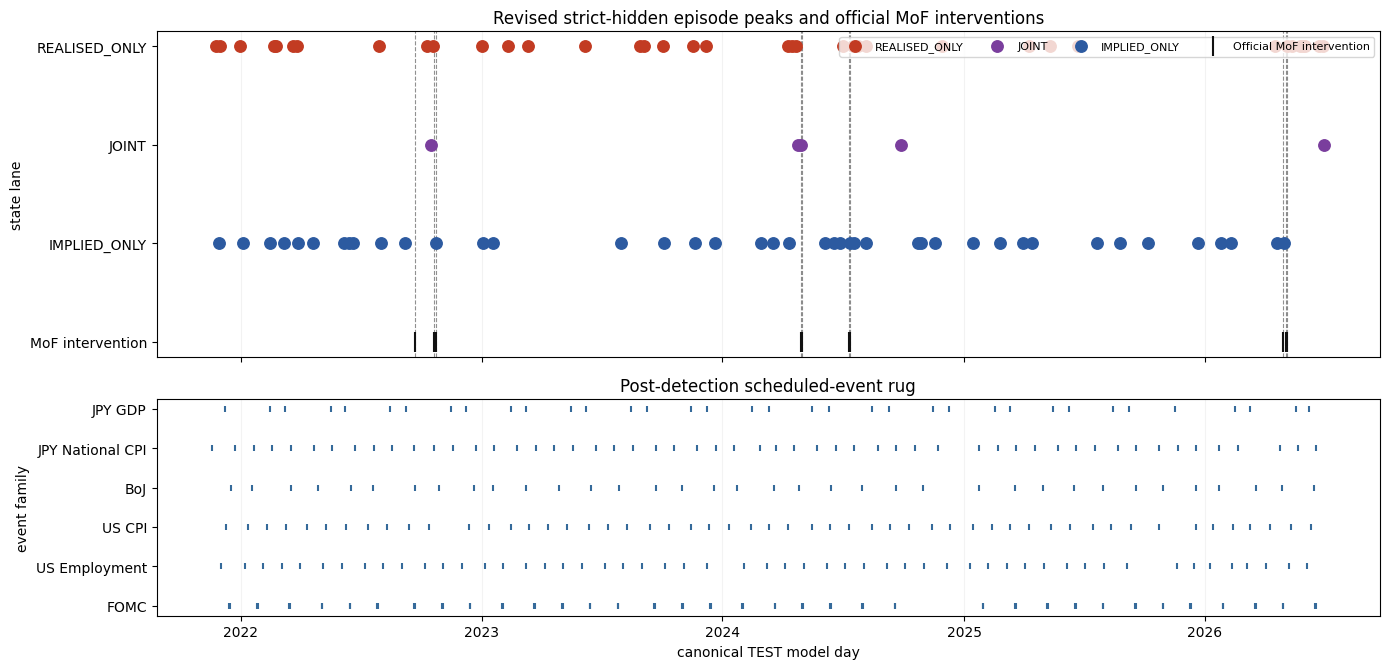

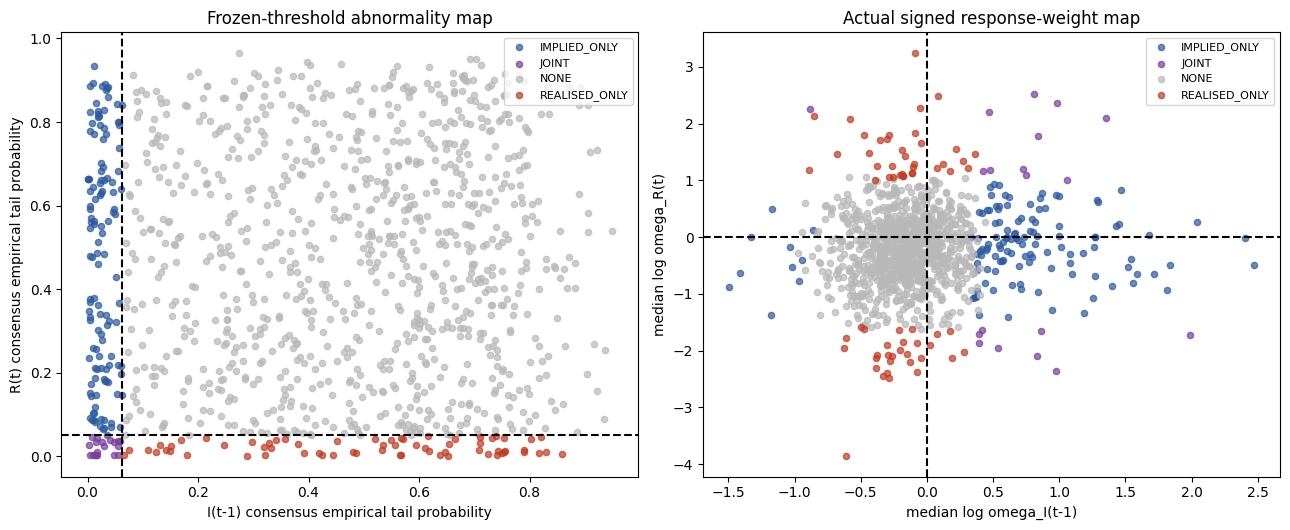

In [46]:
# Headline chronology: sparse revised strict-hidden episode peaks, MoF dates, and a post-detection event rug.
state_colors = {'REALISED_ONLY':'#c23b22','JOINT':'#7a3e9d','IMPLIED_ONLY':'#2c5aa0'}
state_lanes = {'REALISED_ONLY':3,'JOINT':2,'IMPLIED_ONLY':1}
fig, (ax, rug) = plt.subplots(2,1,figsize=(14,6.8),sharex=True,gridspec_kw={'height_ratios':[3,2]})
for state, lane in state_lanes.items():
    part = primary_hidden_episodes.loc[primary_hidden_episodes['primary_state'].eq(state)]
    ax.scatter(part['peak_day'], np.repeat(lane, len(part)), s=68, color=state_colors[state], label=state, zorder=3)
for day in mof_interventions['mapped_model_day']:
    ax.axvline(day, color='#222222', ls='--', lw=.8, alpha=.5)
ax.scatter(mof_interventions['mapped_model_day'], np.zeros(len(mof_interventions)), marker='|', s=190, color='#111111', label='Official MoF intervention', zorder=4)
ax.set_yticks([0,1,2,3], ['MoF intervention','IMPLIED_ONLY','JOINT','REALISED_ONLY'])
ax.set(title='Revised strict-hidden episode peaks and official MoF interventions', ylabel='state lane')
ax.grid(axis='x', alpha=.16); ax.legend(ncol=4, fontsize=8, loc='upper right')
for row, family in enumerate(PRIMARY_FAMILIES):
    r_days = primary_test_scores.loc[primary_test_scores['R_event_families'].str.contains(family,regex=False), 'model_day']
    i_days = primary_test_scores.loc[primary_test_scores['I_prev_event_families'].str.contains(family,regex=False), 'model_day']
    days = pd.Index(r_days).union(pd.Index(i_days))
    rug.scatter(days, np.repeat(row, len(days)), s=18, marker='|', color='#356a9a')
rug.set_yticks(range(len(PRIMARY_FAMILIES)), PRIMARY_FAMILIES)
rug.set(title='Post-detection scheduled-event rug', xlabel='canonical TEST model day', ylabel='event family')
rug.grid(axis='x', alpha=.14); fig.tight_layout()
fig.savefig(FIGURES/'21_figure_hidden_episode_mof_timeline.png',dpi=180)
plt.show()

# Supplementary geometry: tail-score thresholds classify the four states; log weights retain direction.
state_colors_full = {'NONE':'#b8b8b8', **state_colors}
fig, axes = plt.subplots(1,2,figsize=(13,5.4))
for state, part in primary_test_scores.groupby('primary_state'):
    axes[0].scatter(part['consensus_tail_p_I_prev'],part['consensus_tail_p_R'],s=20,color=state_colors_full[state],label=state,alpha=.7)
    axes[1].scatter(part['log_omega_I_prev_consensus'],part['log_omega_R_consensus'],s=20,color=state_colors_full[state],label=state,alpha=.7)
axes[0].axvline(threshold_lookup.loc[('I',.05)],color='black',ls='--'); axes[0].axhline(threshold_lookup.loc[('R',.05)],color='black',ls='--')
axes[0].set(xlabel='I(t-1) consensus empirical tail probability',ylabel='R(t) consensus empirical tail probability',title='Frozen-threshold abnormality map')
axes[1].axvline(0,color='black',ls='--'); axes[1].axhline(0,color='black',ls='--')
axes[1].set(xlabel='median log omega_I(t-1)',ylabel='median log omega_R(t)',title='Actual signed response-weight map')
for axis in axes: axis.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURES/'21_revised_state_maps.png',dpi=180); plt.show()


Left Panel:
- upper-right --> neither abnormal
- lower-right --> realised only
- upper-left --> implied only
- lower-left --> joint

Right Panel:
- upper-right --> both above background
- upper-left --> realised above, implied below
- lower-right --> realised below, implied above
- lower-left --> both below background

## 21.19a Economic context of revised strict-hidden episodes

Statistical abnormality alone does not establish a meaningful economic event. This post-detection table is a descriptive inspection tool: it combines each strict-hidden episode peak’s state, actual response weights, volatility quantities, spot-movement context, calendar context, and nearest official MoF intervention. It changes no detector, threshold, state, episode, or causal interpretation.

The table deliberately retains $\omega_R$ and $\omega_I$: for example, $\omega_R=3$ means realised variance was approximately three times its ordinary model background, while $\omega_I=0.4$ means prior-model-day implied variance was about 40% of its background. Magnitude and empirical tail probability answer different questions.

The frozen N15 daily model panel provides the already-defined signed USD/JPY canonical model-day log return, 'within_session_log_return': the sum of within-session hourly log returns over $[D-1\ 17{:}00\ \mathrm{New\ York}, D\ 17{:}00\ \mathrm{New\ York})$. It is carried here unchanged as 'usdjpy_model_day_return'; N16's 'squared_return' is verified to equal this return squared and is displayed as $Q_t$.

$R_t = 252\sum_{\tau\in t} r_\tau^2$ measures accumulated intraday realised variation, whereas $Q_t=(\sum_{\tau\in t}r_\tau)^2$ measures squared net model-day USD/JPY displacement. Large $R_t$ and large $Q_t$ indicate substantial variation accompanied by a large net move; large $R_t$ with relatively small $Q_t$ indicates substantial intraday movement with less net displacement. The signed return also shows direction. These are post-detection context only.


In [47]:
# One descriptive row per existing strict-hidden episode peak; detector objects are read only.
peak_fields = ['model_day','canonical_index','omega_R_consensus','omega_I_prev_consensus','log_omega_R_consensus','log_omega_I_prev_consensus','consensus_tail_p_R','consensus_tail_p_I_prev','R_abnormal','I_abnormal_prev','R_direction','I_direction','R_event_families','I_prev_event_families','known_primary_event_pair','is_month_end_t','is_month_end_prev','month_end_pair']
peak_rows = primary_hidden_episodes.merge(primary_candidate_days[peak_fields], left_on='peak_day', right_on='model_day', how='left', validate='one_to_one').drop(columns='model_day')
peak_rows = peak_rows.merge(panel[['model_day','R','I','squared_return','usdjpy_model_day_return','abs_usdjpy_model_day_return','previous_model_day']], left_on='peak_day', right_on='model_day', how='left', validate='one_to_one').drop(columns='model_day').rename(columns={'R':'R_t','I':'I_t','squared_return':'Q_t'})
previous_i = panel[['model_day','I']].rename(columns={'model_day':'previous_model_day','I':'I_prev'})
peak_rows = peak_rows.merge(previous_i,on='previous_model_day',how='left',validate='many_to_one')
scheduled = event_mapping.loc[event_mapping['event_label'].isin(PRIMARY_FAMILIES), ['event_label','target_model_day']].merge(panel[['model_day','canonical_index']],left_on='target_model_day',right_on='model_day',how='inner')
scheduled = scheduled.groupby(['canonical_index','model_day'],as_index=False)['event_label'].agg(lambda x:' | '.join(sorted(set(x))))
event_context=[]; mof_context=[]
for row in peak_rows.itertuples(index=False):
    dist = scheduled['canonical_index'] - row.canonical_index
    near = scheduled.loc[dist.abs().eq(dist.abs().min())].sort_values(['model_day','event_label']).iloc[0]
    event_context.append({'hidden_episode_id':row.hidden_episode_id,'nearest_scheduled_event_family':near.event_label,'nearest_scheduled_event_model_day':near.model_day,'scheduled_event_distance_model_days':int(row.canonical_index-near.canonical_index)})
    mof_dist = mof_interventions['mapped_canonical_index'] - row.canonical_index
    mof_near = mof_interventions.loc[mof_dist.abs().eq(mof_dist.abs().min())].sort_values('intervention_date').iloc[0]
    signed = int(row.canonical_index-mof_near.mapped_canonical_index)
    mof_context.append({'hidden_episode_id':row.hidden_episode_id,'nearest_MoF_intervention_date':mof_near.intervention_date,'MoF_distance_model_days':signed,'within_MoF_5_model_days':abs(signed)<=5,'within_MoF_7_model_days':abs(signed)<=7,'within_MoF_10_model_days':abs(signed)<=10})
hidden_episode_economic_context = peak_rows.merge(pd.DataFrame(event_context),on='hidden_episode_id',validate='one_to_one').merge(pd.DataFrame(mof_context),on='hidden_episode_id',validate='one_to_one').sort_values('peak_tail_p').reset_index(drop=True)
hidden_episode_economic_context_summary = hidden_episode_economic_context.groupby('primary_state',as_index=False).agg(n_episodes=('hidden_episode_id','size'),median_omega_R=('omega_R_consensus','median'),median_omega_I_prev=('omega_I_prev_consensus','median'),fraction_month_end=('month_end_pair','mean'),fraction_within_MoF_5=('within_MoF_5_model_days','mean'),fraction_within_5_model_days_of_scheduled_event=('scheduled_event_distance_model_days',lambda x:float((x.abs()<=5).mean())))
context_display_columns = ['peak_day','primary_state','omega_R_consensus','omega_I_prev_consensus','usdjpy_model_day_return','abs_usdjpy_model_day_return','Q_t','R_direction','I_direction','R_t','I_prev','I_t','nearest_scheduled_event_family','scheduled_event_distance_model_days','month_end_pair','nearest_MoF_intervention_date','MoF_distance_model_days']
display(hidden_episode_economic_context[context_display_columns].head(15))
display(hidden_episode_economic_context_summary)


,peak_day,primary_state,omega_R_consensus,omega_I_prev_consensus,usdjpy_model_day_return,abs_usdjpy_model_day_return,Q_t,R_direction,I_direction,R_t,I_prev,I_t,nearest_scheduled_event_family,scheduled_event_distance_model_days,month_end_pair,nearest_MoF_intervention_date,MoF_distance_model_days
0,2021-11-25,REALISED_ONLY,0.090839,0.741822,-0.000555,0.000555,3.075811e-07,BELOW_BACKGROUND,BELOW_BACKGROUND,0.000350,0.004614,0.003148,JPY National CPI,4,False,2022-09-22,-215
1,2024-04-29,JOINT,8.996720,1.597957,-0.009719,0.009719,9.446638e-05,ABOVE_BACKGROUND,ABOVE_BACKGROUND,0.147870,0.028308,0.039107,BoJ,1,False,2024-04-29,0
2,2023-12-07,REALISED_ONLY,6.085333,0.621754,-0.021869,0.021869,4.782439e-04,ABOVE_BACKGROUND,BELOW_BACKGROUND,0.028247,0.006127,0.027963,JPY GDP | US Employment,0,False,2024-04-29,-102
3,2024-09-27,JOINT,5.932843,2.323036,-0.018219,0.018219,3.319378e-04,ABOVE_BACKGROUND,ABOVE_BACKGROUND,0.130765,0.041220,0.019926,US Employment,-4,False,2024-07-12,55
4,2026-05-06,REALISED_ONLY,8.513064,0.427088,-0.009546,0.009546,9.112794e-05,ABOVE_BACKGROUND,BELOW_BACKGROUND,0.043301,0.006959,0.011103,US Employment,-1,False,2026-05-06,0
5,2026-06-29,REALISED_ONLY,0.086551,0.720914,0.001239,0.001239,1.534852e-06,BELOW_BACKGROUND,BELOW_BACKGROUND,0.000220,0.002785,0.002812,JPY National CPI,6,False,2026-05-06,38
6,2024-10-28,IMPLIED_ONLY,0.751092,3.257080,0.000316,0.000316,1.001393e-07,BELOW_BACKGROUND,ABOVE_BACKGROUND,0.011015,0.032361,0.013803,BoJ,-2,False,2024-07-12,76
7,2025-07-21,IMPLIED_ONLY,0.503602,3.574789,-0.003782,0.003782,1.430665e-05,BELOW_BACKGROUND,ABOVE_BACKGROUND,0.007181,0.029169,0.007549,JPY National CPI,1,False,2026-04-30,-203
8,2022-03-28,REALISED_ONLY,6.029288,0.752192,0.015032,0.015032,2.259723e-04,ABOVE_BACKGROUND,BELOW_BACKGROUND,0.037251,0.007203,0.021712,US Employment,-3,False,2022-09-22,-128
9,2021-11-29,IMPLIED_ONLY,1.004328,3.551621,-0.001487,0.001487,2.212597e-06,ABOVE_BACKGROUND,ABOVE_BACKGROUND,0.012163,0.014204,0.007523,US Employment,-3,False,2022-09-22,-213


,primary_state,n_episodes,median_omega_R,median_omega_I_prev,fraction_month_end,fraction_within_MoF_5,fraction_within_5_model_days_of_scheduled_event
0,IMPLIED_ONLY,42,0.769563,1.697120,0.119048,0.095238,0.976190
1,JOINT,5,0.193271,2.295723,0.200000,0.600000,0.800000
2,REALISED_ONLY,38,2.909956,0.789223,0.157895,0.131579,0.973684


### How to inspect an episode peak

Start with the state and the actual $\omega_R$ / $\omega_I$ values: are realised and implied responses above or below their ordinary backgrounds? Then inspect nearby scheduled-event distance, month-end status, and signed MoF distance. Here a negative MoF distance means the hidden peak occurred before the intervention, zero is contemporaneous in canonical model-day time, and positive means after it. A nearby calendar entry is context only; an unexplained episode is not proof of an unobservable or economically novel event, but a candidate for later manual investigation.


## 21.19b Scheduled-event proximity baseline

A strict-hidden episode has no six-family scheduled event on the canonical $R_t/I_{t-1}$ detector pair that assigned its state. It need not be far from a scheduled event. This descriptive audit uses the same observed-model-day positions and exactly the six frozen event families; it does not alter hidden status or add an inferential test.

The all-eligible TEST rate answers how much of the entire detector chronology lies near a scheduled event. The conditional strict-hidden-eligible TEST rate answers how often ordinary TEST dates that could themselves have been classified as strict hidden (their existing known_primary_event_pair flag is false) lie near an event. Strict-hidden episode peaks are compared primarily with that conditional population; the all-TEST comparison remains a calendar-density diagnostic.


In [48]:
# Descriptive only: distances use the existing canonical observed model-day index.
from IPython.display import Markdown
strict_hidden_status_before_proximity = primary_candidate_days[['model_day','strict_hidden_candidate','primary_state']].copy()
eligible_test_pairs = primary_test_scores[['model_day','canonical_index','known_primary_event_pair']].copy().reset_index(drop=True)
assert eligible_test_pairs['model_day'].is_unique and eligible_test_pairs['canonical_index'].is_unique
assert eligible_test_pairs['known_primary_event_pair'].notna().all()
strict_hidden_eligible_test_pairs = eligible_test_pairs.loc[eligible_test_pairs['known_primary_event_pair'].eq(False)].copy().reset_index(drop=True)
assert len(strict_hidden_eligible_test_pairs) <= len(eligible_test_pairs)
assert strict_hidden_eligible_test_pairs['known_primary_event_pair'].eq(False).all()
event_positions = scheduled['canonical_index'].drop_duplicates().sort_values().to_numpy(dtype=int)
assert len(event_positions) > 0

def minimum_scheduled_event_distance(canonical_positions):
    canonical_positions = np.asarray(canonical_positions, dtype=int)
    return np.abs(canonical_positions[:, None] - event_positions[None, :]).min(axis=1)

eligible_test_pairs['nearest_scheduled_event_distance_model_days'] = minimum_scheduled_event_distance(eligible_test_pairs['canonical_index'])
strict_hidden_eligible_test_pairs['nearest_scheduled_event_distance_model_days'] = minimum_scheduled_event_distance(strict_hidden_eligible_test_pairs['canonical_index'])
strict_hidden_episode_peaks = hidden_episode_economic_context[['hidden_episode_id','peak_day','primary_state','canonical_index']].copy()
strict_hidden_episode_peaks['nearest_scheduled_event_distance_model_days'] = minimum_scheduled_event_distance(strict_hidden_episode_peaks['canonical_index'])
baseline_rows = []
for window in [1, 2, 3, 5]:
    all_test_near = eligible_test_pairs['nearest_scheduled_event_distance_model_days'].le(window)
    conditional_near = strict_hidden_eligible_test_pairs['nearest_scheduled_event_distance_model_days'].le(window)
    peak_near = strict_hidden_episode_peaks['nearest_scheduled_event_distance_model_days'].le(window)
    all_test_rate = float(all_test_near.mean())
    conditional_rate = float(conditional_near.mean())
    peak_rate = float(peak_near.mean())
    baseline_rows.append({'window_model_days': window, 'n_eligible_test_pairs': len(eligible_test_pairs), 'n_all_test_near_event': int(all_test_near.sum()), 'all_test_rate': all_test_rate, 'n_strict_hidden_eligible_test_pairs': len(strict_hidden_eligible_test_pairs), 'n_strict_hidden_eligible_near_event': int(conditional_near.sum()), 'strict_hidden_eligible_rate': conditional_rate, 'n_strict_hidden_episodes': len(strict_hidden_episode_peaks), 'n_hidden_peaks_near_event': int(peak_near.sum()), 'hidden_peak_rate': peak_rate, 'hidden_minus_conditional_rate': peak_rate - conditional_rate, 'hidden_to_conditional_enrichment': (peak_rate / conditional_rate) if conditional_rate > 0 else np.nan, 'hidden_minus_all_test_rate': peak_rate - all_test_rate, 'hidden_to_all_test_enrichment': (peak_rate / all_test_rate) if all_test_rate > 0 else np.nan})
scheduled_event_proximity_baseline = pd.DataFrame(baseline_rows)
state_rows = []
for state in ['REALISED_ONLY','IMPLIED_ONLY','JOINT']:
    state_peaks = strict_hidden_episode_peaks.loc[strict_hidden_episode_peaks['primary_state'].eq(state)]
    state_rows.append({'primary_state': state, 'n_episodes': len(state_peaks), 'n_within_5': int(state_peaks['nearest_scheduled_event_distance_model_days'].le(5).sum()), 'within_5_rate': float(state_peaks['nearest_scheduled_event_distance_model_days'].le(5).mean()) if len(state_peaks) else np.nan})
scheduled_event_proximity_by_state = pd.DataFrame(state_rows)
scheduled_event_proximity_audit = pd.DataFrame([{'uses_canonical_index': True, 'event_positions_are_panel_positions': set(event_positions).issubset(set(panel['canonical_index'])), 'conditional_excludes_known_primary_event_pairs': strict_hidden_eligible_test_pairs['known_primary_event_pair'].eq(False).all(), 'conditional_uses_primary_test_eligible_pairs': set(strict_hidden_eligible_test_pairs['model_day']).issubset(set(primary_test_scores['model_day'])), 'n_eligible_test_pairs': len(eligible_test_pairs), 'n_strict_hidden_eligible_test_pairs': len(strict_hidden_eligible_test_pairs), 'n_strict_hidden_episode_peaks': len(strict_hidden_episode_peaks)}])
display(scheduled_event_proximity_baseline)
display(scheduled_event_proximity_by_state)
window_five = scheduled_event_proximity_baseline.loc[scheduled_event_proximity_baseline['window_model_days'].eq(5)].iloc[0]
if window_five['hidden_to_conditional_enrichment'] > 1.05:
    proximity_interpretation = 'After conditioning on dates eligible for strict-hidden classification, episode peaks remain more concentrated near scheduled macro events. This is consistent with anticipation, persistence, or delayed adjustment, but does not establish causality.'
elif window_five['hidden_to_conditional_enrichment'] < 0.95:
    proximity_interpretation = 'Strict-hidden episode peaks are not unusually concentrated near the scheduled-event calendar relative to otherwise eligible TEST dates.'
else:
    proximity_interpretation = 'Once the baseline is conditioned on dates eligible for strict-hidden classification, the apparent proximity of hidden episodes is largely explained by the density of the event calendar.'
display(Markdown(f"At the primary +/-5 model-day window, {window_five['hidden_peak_rate']:.1%} of strict-hidden episode peaks are near a scheduled event versus {window_five['strict_hidden_eligible_rate']:.1%} of strict-hidden-eligible TEST pairs (difference {window_five['hidden_minus_conditional_rate']:.1%}; enrichment {window_five['hidden_to_conditional_enrichment']:.2f}x). The all-eligible TEST rate is {window_five['all_test_rate']:.1%}. {proximity_interpretation}"))


,window_model_days,n_eligible_test_pairs,n_all_test_near_event,all_test_rate,n_strict_hidden_eligible_test_pairs,n_strict_hidden_eligible_near_event,strict_hidden_eligible_rate,n_strict_hidden_episodes,n_hidden_peaks_near_event,hidden_peak_rate,hidden_minus_conditional_rate,hidden_to_conditional_enrichment,hidden_minus_all_test_rate,hidden_to_all_test_enrichment
0,1,1132,752,0.664311,848,468,0.551887,85,46,0.541176,-0.010710,0.980593,-0.123134,0.814643
1,2,1132,929,0.820671,848,645,0.760613,85,67,0.788235,0.027622,1.036316,-0.032436,0.960476
2,3,1132,1041,0.919611,848,757,0.892689,85,73,0.858824,-0.033865,0.962064,-0.060788,0.933898
3,5,1132,1116,0.985866,848,832,0.981132,85,82,0.964706,-0.016426,0.983258,-0.021160,0.978537


,primary_state,n_episodes,n_within_5,within_5_rate
0,REALISED_ONLY,38,37,0.973684
1,IMPLIED_ONLY,42,41,0.976190
2,JOINT,5,4,0.800000


At the primary +/-5 model-day window, 96.5% of strict-hidden episode peaks are near a scheduled event versus 98.1% of strict-hidden-eligible TEST pairs (difference -1.6%; enrichment 0.98x). The all-eligible TEST rate is 98.6%. Once the baseline is conditioned on dates eligible for strict-hidden classification, the apparent proximity of hidden episodes is largely explained by the density of the event calendar.

## 21.20 Exercise 7: exploratory forward information

Exercise 7 asks whether strict hidden REALISED_ONLY, IMPLIED_ONLY, and JOINT states are descriptively associated with subsequent realised or implied dynamics relative to the control group. The output reports sample sizes, forward outcomes, and uncertainty. These are exploratory predictive-information comparisons, not trading profits; any small JOINT sample must be interpreted cautiously.


In [49]:
ex7 = primary_test_scores[['model_day','canonical_index','primary_state','strict_hidden_candidate','consensus_tail_p_R','consensus_tail_p_I_prev']].merge(panel[['model_day','R','I']],on='model_day',how='left',validate='one_to_one').sort_values('canonical_index').reset_index(drop=True)
for h in [1,5]:
    ex7[f'R_plus_{h}'] = ex7['R'].shift(-h)
    ex7[f'I_plus_{h}'] = ex7['I'].shift(-h)
    ex7[f'log_R_change_{h}'] = np.log(ex7[f'R_plus_{h}']) - np.log(ex7['R'])
    ex7[f'log_I_change_{h}'] = np.log(ex7[f'I_plus_{h}']) - np.log(ex7['I'])
ex7['exercise7_state'] = np.where(ex7['strict_hidden_candidate'],ex7['primary_state'],'NON_HIDDEN_CONTROL')
exercise7_forward_information = ex7.groupby('exercise7_state',as_index=False).agg(n_model_days=('model_day','size'),mean_log_R_change_1=('log_R_change_1','mean'),median_log_R_change_1=('log_R_change_1','median'),mean_log_I_change_1=('log_I_change_1','mean'),median_log_I_change_1=('log_I_change_1','median'),mean_log_R_change_5=('log_R_change_5','mean'),mean_log_I_change_5=('log_I_change_5','mean'))
exercise7_forward_information['standard_error_R_1'] = ex7.groupby('exercise7_state')['log_R_change_1'].sem().to_numpy()
exercise7_forward_information['standard_error_I_1'] = ex7.groupby('exercise7_state')['log_I_change_1'].sem().to_numpy()
display(exercise7_forward_information)


,exercise7_state,n_model_days,mean_log_R_change_1,median_log_R_change_1,mean_log_I_change_1,median_log_I_change_1,mean_log_R_change_5,mean_log_I_change_5,standard_error_R_1,standard_error_I_1
0,IMPLIED_ONLY,44,-0.118173,-0.041923,0.025428,-0.002215,-0.379594,-0.076548,0.114282,0.058252
1,JOINT,6,0.048246,0.457413,-0.178876,-0.172642,0.619652,-0.517665,1.155745,0.342599
2,NON_HIDDEN_CONTROL,1039,-0.000134,-0.050920,0.003878,-0.021240,0.008717,0.007476,0.028544,0.015626
3,REALISED_ONLY,43,0.099815,-0.108761,-0.073132,-0.133120,-0.113100,-0.026254,0.227475,0.077367


## 21.21 Ex-ante $S_t$ signal analysis

$$S_t=\operatorname{median}_m\log\left(\frac{I_{t-1}}{\widehat F^{R,\mathrm{adm}}_{m,t}}\right).$$

$S_t>0$ means implied variance is rich relative to the ordinary realised-background benchmark, and $S_t<0$ means it is cheap. Crucially, $S_t$ is available before $R_t$. This differs from `hidden_state_primary`, which is ex post for model day $t$ because it needs the realised outcome. Since $S_t$ and realised response share the same denominator, evidence is benchmark-relative rather than an independent causal experiment.


In [50]:
r_forecasts = ratios.loc[ratios['target'].eq('R') & ratios['model'].isin(FLEXIBLE_MODELS), ['model_day','sample_split','model','ordinary_background_forecast']].merge(panel[['model_day','R','previous_model_day']],on='model_day',how='left',validate='many_to_one')
prior_I = panel[['model_day','I']].rename(columns={'model_day':'previous_model_day','I':'I_prev'})
r_forecasts = r_forecasts.merge(prior_I,on='previous_model_day',how='left',validate='many_to_one')
r_forecasts['signal_component'] = np.where(r_forecasts['I_prev'].gt(0) & r_forecasts['ordinary_background_forecast'].gt(0),np.log(r_forecasts['I_prev']/r_forecasts['ordinary_background_forecast']),np.nan)
signal = r_forecasts.groupby(['model_day','sample_split','previous_model_day'],as_index=False).agg(S=('signal_component','median'),n_models=('signal_component','count'))
validation_signal = signal.loc[signal['sample_split'].eq('validation'),'S']
S_cheap,S_rich = validation_signal.quantile([.2,.8])
signal['signal_group'] = np.select([signal['S'].le(S_cheap),signal['S'].ge(S_rich)],['IMPLIED_CHEAP','IMPLIED_RICH'],default='NEUTRAL')
signal['validation_defined_quintile'] = np.select([signal['S'].le(S_cheap),signal['S'].ge(S_rich)],['LOWEST_QUINTILE','HIGHEST_QUINTILE'],default='MIDDLE_QUINTILES')
signal_timing_audit = pd.DataFrame([{'signal_definition':'median log(I_{t-1}/F_R_adm_t)','timing':'EX_ANTE_BEFORE_R_T','threshold_source':'VALIDATION','S_cheap':S_cheap,'S_rich':S_rich}])
display(signal_timing_audit)


,signal_definition,timing,threshold_source,S_cheap,S_rich
0,median log(I_{t-1}/F_R_adm_t),EX_ANTE_BEFORE_R_T,VALIDATION,-0.061313,0.218425


## 21.22 Application-state panel and timing

The application panel explicitly distinguishes ex-ante signal information from ex-post hidden-state information. A model-day hidden state must not be treated as tradable before the same outcome that determines it. The timing fields are therefore part of the handoff contract for N22 onward.


In [51]:
application_state_panel = panel[['model_day','previous_model_day','sample_split','canonical_index','next_model_day']].merge(primary_pairs[['model_day','primary_state','is_candidate','strict_hidden_candidate','R_abnormal','I_abnormal_prev','R_direction','I_direction','omega_R_consensus','omega_I_prev_consensus','log_omega_R_consensus','log_omega_I_prev_consensus','consensus_tail_p_R','consensus_tail_p_I_prev','known_primary_event_pair','R_event_families','I_prev_event_families','month_end_pair']],on='model_day',how='left',validate='one_to_one').merge(primary_candidate_days[['model_day','hidden_episode_id']],on='model_day',how='left',validate='one_to_one').merge(signal[['model_day','S','signal_group','validation_defined_quintile']],on='model_day',how='left',validate='one_to_one')
application_state_panel['hidden_state_primary'] = np.where(application_state_panel['sample_split'].eq('test'),application_state_panel['primary_state'].fillna('NONE'),'NOT_EVALUATED')
for col in ['is_candidate','strict_hidden_candidate','R_abnormal','I_abnormal_prev','known_primary_event_pair','month_end_pair']:
    application_state_panel[col]=application_state_panel[col].fillna(False).astype(bool)
for col in ['hidden_episode_id','R_event_families','I_prev_event_families']:
    application_state_panel[col]=application_state_panel[col].fillna('')
application_state_panel['signal_group']=application_state_panel['signal_group'].fillna('NOT_EVALUATED')
application_state_panel['validation_defined_quintile']=application_state_panel['validation_defined_quintile'].fillna('NOT_EVALUATED')
application_state_panel['hidden_state_information_timing']='AVAILABLE_AFTER_MODEL_DAY_T'
application_state_panel['signal_information_timing']='EX_ANTE_BEFORE_R_T'
display(application_state_panel.head())


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_16556\2280341553.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  application_state_panel[col]=application_state_panel[col].fillna(False).astype(bool)
C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_16556\2280341553.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  application_state_panel[col]=application_state_panel[col].fillna(False).astype(bool)
C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_16556\2280341553.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is de

,model_day,previous_model_day,sample_split,canonical_index,next_model_day,primary_state,is_candidate,strict_hidden_candidate,R_abnormal,I_abnormal_prev,...,R_event_families,I_prev_event_families,month_end_pair,hidden_episode_id,S,signal_group,validation_defined_quintile,hidden_state_primary,hidden_state_information_timing,signal_information_timing
0,2003-05-05,NaT,train,0,2003-05-06,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T
1,2003-05-06,2003-05-05,train,1,2003-05-07,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T
2,2003-05-07,2003-05-06,train,2,2003-05-08,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T
3,2003-05-08,2003-05-07,train,3,2003-05-09,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T
4,2003-05-09,2003-05-08,train,4,2003-05-12,NaN,False,False,False,False,...,,,False,,NaN,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T


## 21.23 Approximate legacy disagreement-detector comparison

The supplementary historical comparator follows empirical percentiles, inverse-normal scores, and

$$D_t=Z_R(t)-Z_I(t-1).$$

It is retained for robustness and historical comparison, not because it is invalid. Direct subtraction can obscure simultaneous abnormalities, so it is no longer primary. This implementation is approximate because it reconstructs the method from current frozen N20 ratios rather than a saved historical detector artifact; it cannot affect revised-primary conclusions.


In [52]:
from scipy.stats import norm
legacy_parts=[]
for (target,model),group in ratios.loc[ratios['model'].isin(FLEXIBLE_MODELS)].groupby(['target','model']):
    ref=group.loc[group['sample_split'].eq('validation') & bool_flag(group['ratio_defined']),'ordinary_response_ratio'].sort_values().to_numpy(float)
    part=group.loc[bool_flag(group['ratio_defined'])].copy()
    part['legacy_percentile']=(np.searchsorted(ref,part['ordinary_response_ratio'],side='right')+.5)/(len(ref)+1)
    legacy_parts.append(part)
legacy_scores=pd.concat(legacy_parts)
legacy_consensus=legacy_scores.groupby(['model_day','sample_split','target'],as_index=False).agg(legacy_percentile=('legacy_percentile','median'),n_models=('model','nunique'))
legacy_consensus=legacy_consensus.loc[legacy_consensus['n_models'].ge(MIN_MODEL_SUPPORT)].copy(); legacy_consensus['legacy_z']=norm.ppf(legacy_consensus['legacy_percentile'])
lr=legacy_consensus.loc[legacy_consensus['target'].eq('R')].rename(columns={'model_day':'model_day','legacy_z':'Z_R','legacy_percentile':'P_R'})
li=legacy_consensus.loc[legacy_consensus['target'].eq('I')].rename(columns={'model_day':'previous_model_day','legacy_z':'Z_I_prev','legacy_percentile':'P_I_prev','sample_split':'previous_sample_split'})
legacy_pairs=panel[['model_day','previous_model_day','sample_split','previous_sample_split']].merge(lr[['model_day','sample_split','Z_R','P_R']],on=['model_day','sample_split']).merge(li[['previous_model_day','previous_sample_split','Z_I_prev','P_I_prev']],on=['previous_model_day','previous_sample_split'])
legacy_pairs['D']=legacy_pairs['Z_R']-legacy_pairs['Z_I_prev']
legacy_validation=legacy_pairs.loc[legacy_pairs['sample_split'].eq('validation'),'D']; lo,hi=legacy_validation.quantile([.01,.99])
legacy_pairs['legacy_candidate']=((legacy_pairs['D'].ge(hi)&legacy_pairs['P_R'].ge(.95))|(legacy_pairs['D'].le(lo)&legacy_pairs['P_I_prev'].ge(.95)))
legacy_test=legacy_pairs.loc[legacy_pairs['sample_split'].eq('test') & legacy_pairs['legacy_candidate']]
legacy_detector_comparison=pd.DataFrame([{'legacy_candidate_count':len(legacy_test),'revised_candidate_count':len(primary_all_candidate_days),'overlap_count':len(set(legacy_test['model_day'])&set(primary_all_candidate_days['model_day'])),'revised_only_dates':' | '.join(pd.Series(sorted(set(primary_all_candidate_days['model_day'])-set(legacy_test['model_day']))).dt.strftime('%Y-%m-%d')),'legacy_only_dates':' | '.join(pd.Series(sorted(set(legacy_test['model_day'])-set(primary_all_candidate_days['model_day']))).dt.strftime('%Y-%m-%d'))}])
display(legacy_detector_comparison)


,legacy_candidate_count,revised_candidate_count,overlap_count,revised_only_dates,legacy_only_dates
0,32,209,31,2021-11-25 | 2021-11-29 | 2021-11-30 | 2021-12...,2022-03-02


## 21.24 Transition to the authoritative final closure


### Superseded pre-cleanup closure

The closure below is deliberately superseded by the authoritative final closure at the true end of this notebook.  It is not executed or presented as certification of the corrected post-detection objects.

## 21.25 Corrected post-detection interpretation


### Corrected known-event attribution and descriptive cross-channel interpretation

The detector remains frozen: it pairs $R_t$ with the immediately previous observed canonical-model-day $I_{t-1}$, uses the existing ordinary-VALIDATION empirical tails and $\alpha=0.05$, and is not retuned here.  The N18 target-specific map is used only after detection: FOMC contributes $R_D/I_D$ attribution, while the other five families contribute $R_D/I_{D-1}$ attribution.  Thus strict-hidden means a frozen candidate with neither mapped known-event leg in its detector pair.

For descriptive interpretation, the robust consensus log responses are $L_R=\log(\omega_R)$ and $L_{I,prev}=\log(\omega_{I,prev})$.  We report $\Delta L=L_R-L_{I,prev}$ (positive: realised response is larger than implied) and $\bar L=(L_R+L_{I,prev})/2$.  These are economic-response coordinates only, not detector inputs or standardised abnormality scores.  Direction labels distinguish amplification above background from suppression below background; neither changes a candidate state or an episode.

Forecast-floor flags are carried directly from N20's raw/admissible forecasts for the contributing flexible-model rows.  The floor comparison and low-side realised peak audit are descriptive provenance checks, not an alternative detector.  MoF overlap is post-hoc external validation: the predeclared $\alpha\in\{0.10,0.05,0.01\}$ and $\pm5/\pm7/\pm10$ canonical-model-day windows are reported using every one of the 1,209 circular TEST offsets.


### Visible implementation of corrected attribution and interpretation

These cells are the canonical, readable implementation of the frozen post-detection layer.

### Corrected timing annotation, $\Delta L$, common log response, and directions

$\Delta L=L_R-L_{I,prev}=\log(\omega_R/\omega_{I,prev})$; positive values mean the realised response ratio dominates.  The common coordinate is $\bar L=(L_R+L_{I,prev})/2$.  Both are descriptive only.

In [53]:
# Final post-detection timing and interpretation layer.
n18=pd.read_csv(PROCESSED/'18_target_specific_event_mapping.csv',parse_dates=['realised_model_day','implied_model_day','target_model_day'])
n18=n18.loc[n18.family.isin(PRIMARY_FAMILIES)].copy()
offsets={'FOMC':0,'US Employment':-1,'US CPI':-1,'BoJ':-1,'JPY National CPI':-1,'JPY GDP':-1}
assert n18.realised_event_offset.eq(0).all() and all(n18.loc[n18.family.eq(f),'implied_event_offset'].eq(o).all() for f,o in offsets.items())
idx=panel.set_index('model_day').canonical_index; minus=n18.implied_event_offset.eq(-1)
assert n18.loc[minus,'implied_model_day'].map(idx).eq(n18.loc[minus,'realised_model_day'].map(idx)-1).all()
def fmap(target):
 x=n18.loc[n18.target.eq(target),['target_model_day','family']].drop_duplicates()
 return x.groupby('target_model_day').family.agg(lambda y:' | '.join(sorted(set(y)))).to_dict()
snapshot=primary_pairs[['model_day','primary_state','is_candidate','R_abnormal','I_abnormal_prev','consensus_tail_p_R','consensus_tail_p_I_prev']].copy()
primary_pairs['R_event_families']=primary_pairs.model_day.map(fmap('R')).fillna('')
primary_pairs['I_prev_event_families']=primary_pairs.previous_model_day.map(fmap('I')).fillna('')
primary_pairs['known_event_R']=primary_pairs.R_event_families.ne('')
primary_pairs['known_event_I_prev']=primary_pairs.I_prev_event_families.ne('')
primary_pairs['known_primary_event_pair']=primary_pairs.known_event_R|primary_pairs.known_event_I_prev
primary_pairs['strict_hidden_candidate']=primary_pairs.is_candidate&~primary_pairs.known_primary_event_pair
# Median available model-specific log responses define the descriptive robust centres.
primary_pairs['L_R']=primary_pairs.log_omega_R_consensus; primary_pairs['L_I_prev']=primary_pairs.log_omega_I_prev_consensus
primary_pairs['Delta_L']=primary_pairs.L_R-primary_pairs.L_I_prev
primary_pairs['common_log_response']=(primary_pairs.L_R+primary_pairs.L_I_prev)/2
primary_pairs['response_ratio_R_over_I']=np.exp(primary_pairs.Delta_L)
def direction2(x): return np.select([x>1e-12,x<-1e-12],['ABOVE_BACKGROUND','BELOW_BACKGROUND'],default='AT_BACKGROUND')
primary_pairs['R_response_direction']=direction2(primary_pairs.L_R); primary_pairs['I_response_direction']=direction2(primary_pairs.L_I_prev)
primary_pairs['state_direction_group']=np.select([
 primary_pairs.primary_state.eq('REALISED_ONLY')&primary_pairs.R_response_direction.eq('ABOVE_BACKGROUND'),
 primary_pairs.primary_state.eq('REALISED_ONLY')&primary_pairs.R_response_direction.eq('BELOW_BACKGROUND'),
 primary_pairs.primary_state.eq('IMPLIED_ONLY')&primary_pairs.I_response_direction.eq('ABOVE_BACKGROUND'),
 primary_pairs.primary_state.eq('IMPLIED_ONLY')&primary_pairs.I_response_direction.eq('BELOW_BACKGROUND'),
 primary_pairs.primary_state.eq('JOINT')&primary_pairs.R_response_direction.eq('ABOVE_BACKGROUND')&primary_pairs.I_response_direction.eq('ABOVE_BACKGROUND'),
 primary_pairs.primary_state.eq('JOINT')&primary_pairs.R_response_direction.eq('ABOVE_BACKGROUND')&primary_pairs.I_response_direction.eq('BELOW_BACKGROUND'),
 primary_pairs.primary_state.eq('JOINT')&primary_pairs.R_response_direction.eq('BELOW_BACKGROUND')&primary_pairs.I_response_direction.eq('ABOVE_BACKGROUND'),
 primary_pairs.primary_state.eq('JOINT')&primary_pairs.R_response_direction.eq('BELOW_BACKGROUND')&primary_pairs.I_response_direction.eq('BELOW_BACKGROUND')],
 ['REALISED_ONLY_R_ABOVE','REALISED_ONLY_R_BELOW','IMPLIED_ONLY_I_ABOVE','IMPLIED_ONLY_I_BELOW','JOINT_R_ABOVE_I_ABOVE','JOINT_R_ABOVE_I_BELOW','JOINT_R_BELOW_I_ABOVE','JOINT_R_BELOW_I_BELOW'],default='NONE_OR_AT_BACKGROUND')
assert np.allclose(primary_pairs.L_R,primary_pairs.common_log_response+primary_pairs.Delta_L/2,equal_nan=True)
assert np.allclose(primary_pairs.L_I_prev,primary_pairs.common_log_response-primary_pairs.Delta_L/2,equal_nan=True)


### Forecast-floor provenance and response-direction summaries

Floor flags are inherited directly from N20 raw/admissible forecast fields and do not alter the detector.

In [54]:
# Use N20 floor_activated directly, restricted to log-eligible participating primary model rows.
f=model_scores.loc[model_scores.model.isin(FLEXIBLE_MODELS)&model_scores.log_eligible&model_scores.p_emp.notna()].copy(); f['floor_activated']=bool_flag(f.floor_activated)
def floors(target,key,label):
 x=f.loc[f.target.eq(target),['model_day','model','floor_activated']].groupby('model_day',as_index=False).agg(**{f'n_floor_{label}':('floor_activated','sum'),f'n_contributing_{label}_models':('model','nunique')})
 x[f'any_floor_{label}']=x[f'n_floor_{label}'].gt(0); return x.rename(columns={'model_day':key})
primary_pairs=primary_pairs.merge(floors('R','model_day','R'),on='model_day',how='left').merge(floors('I','previous_model_day','I_prev'),on='previous_model_day',how='left')
for c in ['n_floor_R','n_floor_I_prev','n_contributing_R_models','n_contributing_I_prev_models']: primary_pairs[c]=primary_pairs[c].fillna(0).astype(int)
for c in ['any_floor_R','any_floor_I_prev']: primary_pairs[c]=primary_pairs[c].fillna(False).astype(bool)
assert primary_pairs.n_contributing_R_models.eq(primary_pairs.n_models_R).all() and primary_pairs.n_contributing_I_prev_models.eq(primary_pairs.n_models_I).all()
primary_test_scores=primary_pairs.loc[primary_pairs.sample_split.eq('test')].copy()
assert int(primary_test_scores.is_candidate.sum())==209,'Frozen ordinary response input changed: alpha=.05 candidate count is not 209.'
assert snapshot.equals(primary_pairs[snapshot.columns])
primary_all_candidate_days=primary_test_scores.loc[primary_test_scores.is_candidate].sort_values('canonical_index').copy()
primary_candidate_days,primary_hidden_episodes=build_episodes(primary_test_scores.copy(),'primary_state','strict_hidden_candidate','E21_PRIMARY_')
strict=primary_candidate_days.copy()
cross_channel_response_summary=strict.groupby(['primary_state','state_direction_group'],as_index=False).agg(n_days=('model_day','size'),median_Delta_L=('Delta_L','median'),q25_Delta_L=('Delta_L',lambda x:x.quantile(.25)),q75_Delta_L=('Delta_L',lambda x:x.quantile(.75)),median_common_log_response=('common_log_response','median'),q25_common_log_response=('common_log_response',lambda x:x.quantile(.25)),q75_common_log_response=('common_log_response',lambda x:x.quantile(.75))).rename(columns={'state_direction_group':'group'})
hidden_state_direction_summary=strict.groupby(['primary_state','state_direction_group'],as_index=False).agg(n_days=('model_day','size'),n_episodes=('hidden_episode_id','nunique'))
strict['floor_condition']=np.where(strict.any_floor_R|strict.any_floor_I_prev,'ANY_FLOOR','NO_FLOOR_EITHER_LEG')
floor_provenance_summary=strict.groupby('floor_condition',as_index=False).agg(n_days=('model_day','size'),median_Delta_L=('Delta_L','median'),median_common_log_response=('common_log_response','median'))
floor_provenance_summary['share_of_strict_hidden_days']=floor_provenance_summary.n_days/len(strict)


### Low-side realised-response diagnostic

This diagnostic retains below-background realised-only episode peaks as interpretive evidence; it is not an exclusion rule.

In [55]:
# Compact, provenance-clean low-side realised-only peak audit.  This is descriptive only.
rbg = (f.loc[f.target.eq('R'), ['model_day','admissible_forecast']]
       .groupby('model_day', as_index=False).admissible_forecast.median()
       .rename(columns={'admissible_forecast':'robust_ordinary_R_background'}))
low_peaks = primary_hidden_episodes.loc[primary_hidden_episodes.primary_state.eq('REALISED_ONLY'), ['hidden_episode_id','peak_day']].rename(columns={'hidden_episode_id':'episode_id','peak_day':'model_day'})
low_side_realised_diagnostic = (low_peaks
    .merge(strict[['model_day','canonical_index','R_response_direction','omega_R_consensus','L_R','Delta_L','common_log_response','n_models_R','n_floor_R']], on='model_day', how='left', validate='one_to_one')
    .loc[lambda x: x.R_response_direction.eq('BELOW_BACKGROUND')]
    .merge(panel[['model_day','R','I']], on='model_day', how='left', validate='one_to_one')
    .merge(rbg, on='model_day', how='left', validate='one_to_one')
    .rename(columns={'R':'actual_R','omega_R_consensus':'consensus_omega_R','L_R':'consensus_L_R','n_models_R':'n_valid_R_models'}))
r_model_omega = f.loc[f.target.eq('R'), ['model_day','model','response_ratio']].pivot_table(index='model_day', columns='model', values='response_ratio', aggfunc='first').rename(columns=lambda x: f'omega_R_{str(x).upper()}').reset_index()
r_below = (f.loc[f.target.eq('R'), ['model_day','response_ratio']]
           .groupby('model_day', as_index=False).response_ratio
           .agg(lambda x: int((x < 1).sum()))
           .rename(columns={'response_ratio':'n_models_omega_R_below_1'}))
low_side_realised_diagnostic = low_side_realised_diagnostic.merge(r_model_omega, on='model_day', how='left').merge(r_below, on='model_day', how='left', validate='one_to_one')
low_side_realised_diagnostic['n_models_omega_R_below_1'] = low_side_realised_diagnostic['n_models_omega_R_below_1'].fillna(0).astype(int)
low_side_realised_diagnostic['recent_R_history'] = low_side_realised_diagnostic.canonical_index.map(lambda i: ' | '.join(f'{x:.6g}' for x in panel.loc[(panel.canonical_index < i) & (panel.canonical_index >= i-5), 'R']))
low_side_realised_diagnostic['recent_I_history'] = low_side_realised_diagnostic.canonical_index.map(lambda i: ' | '.join(f'{x:.6g}' for x in panel.loc[(panel.canonical_index < i) & (panel.canonical_index >= i-5), 'I']))
low_columns = ['episode_id','model_day','actual_R','robust_ordinary_R_background','consensus_omega_R','consensus_L_R','Delta_L','common_log_response','n_valid_R_models','n_models_omega_R_below_1','n_floor_R','recent_R_history','recent_I_history'] + [f'omega_R_{m}' for m in ['RF','GB','MLP','TRANSFORMER'] if f'omega_R_{m}' in low_side_realised_diagnostic]
low_side_realised_diagnostic = low_side_realised_diagnostic[low_columns].sort_values('model_day').reset_index(drop=True)


### MoF alpha profile and canonical nearest-distance audit

MoF is post-hoc external validation.  The primary specification remains $\alpha=0.05$ and $\pm5$ canonical model days; all 1,209 circular offsets are retained. At primary alpha the observed intervention-date hits saturate at nine: widening to $\pm7$ or $\pm10$ adds no matches but increases expected overlap under the circular-shift null, so the wider windows carry progressively less discriminatory information rather than representing independent robustness failures.

In [56]:
# Predeclared alpha and MoF profile; every circular offset of the 1,209 TEST rows is used.
profiles=[]; nearest=[]; nulls=[]; sensitivity=[]; start=int(test_panel.canonical_index.min())
for a in SENSITIVITY_ALPHAS:
 q=primary_test_scores.copy(); q['ra']=q.consensus_tail_p_R.le(threshold_lookup.loc[('R',a)]); q['ia']=q.consensus_tail_p_I_prev.le(threshold_lookup.loc[('I',a)])
 q['state_a']=np.select([q.ra&~q.ia,~q.ra&q.ia,q.ra&q.ia],['REALISED_ONLY','IMPLIED_ONLY','JOINT'],default='NONE'); q['strict_a']=q.state_a.ne('NONE')&~q.known_primary_event_pair
 _,eps=build_episodes(q.assign(primary_state=q.state_a,strict_hidden_candidate=q.strict_a,R_abnormal=q.ra,I_abnormal_prev=q.ia),'primary_state','strict_hidden_candidate',f'E21_A{int(a*100):02d}_')
 sensitivity.append({'alpha':a,'candidate_day_count':int(q.state_a.ne('NONE').sum()),'strict_hidden_candidate_day_count':int(q.strict_a.sum()),'strict_hidden_episode_count':len(eps)})
 peaks=eps.merge(panel[['model_day','canonical_index']],left_on='peak_day',right_on='model_day',how='left').drop(columns='model_day')
 for m in mof_interventions.itertuples(index=False):
  d=peaks.canonical_index.to_numpy(int)-int(m.mapped_canonical_index); z=int(abs(d).min()); p=peaks.loc[(abs(d)==z)].sort_values(['peak_day','hidden_episode_id']).iloc[0]; sd=int(p.canonical_index-m.mapped_canonical_index)
  nearest.append({'alpha':a,'intervention_date':m.intervention_date,'nearest_episode_id':p.hidden_episode_id,'nearest_episode_type':p.primary_state,'signed_distance_model_days':sd,'absolute_distance_model_days':z,'within_5':abs(sd)<=5,'within_7':abs(sd)<=7,'within_10':abs(sd)<=10})
 ep=peaks.canonical_index.to_numpy(int)-start; ip=mof_interventions.mapped_canonical_index.to_numpy(int)-start; camps=mof_interventions.campaign_id.to_numpy(object)
 for s in range(len(test_panel)):
  d=abs(ip[:,None]-((ep+s)%len(test_panel))[None,:])
  for w in [5,7,10]:
   h=(d<=w).any(axis=1); nulls.append({'alpha':a,'shift':s,'window_model_days':w,'date_hit_count':int(h.sum()),'campaign_hit_count':int(sum(h[camps==c].any() for c in mof_campaigns.campaign_id))})
 z=pd.DataFrame([x for x in nearest if x['alpha']==a]).merge(mof_interventions[['intervention_date','campaign_id']],on='intervention_date',how='left',validate='many_to_one')
 for w in [5,7,10]:
  obs=int(z[f'within_{w}'].sum()); obs_campaign=int(z.loc[z[f'within_{w}']].groupby('campaign_id').size().size); n=pd.DataFrame([x for x in nulls if x['alpha']==a and x['window_model_days']==w])
  profiles.append({'alpha':a,'window_model_days':w,'role':'PRIMARY' if a==.05 and w==5 else 'SENSITIVITY','n_strict_hidden_episodes':len(eps),'date_hit_count':obs,'date_hit_null_mean':n.date_hit_count.mean(),'date_hit_randomisation_p':(n.date_hit_count>=obs).mean(),'campaign_hit_count':obs_campaign,'n_campaigns':int(mof_campaigns.campaign_id.nunique()),'campaign_hit_rate':obs_campaign/int(mof_campaigns.campaign_id.nunique()),'campaign_null_mean':n.campaign_hit_count.mean(),'campaign_randomisation_p_value':(n.campaign_hit_count>=obs_campaign).mean()})
primary_threshold_sensitivity=pd.DataFrame(sensitivity); mof_alpha_profile=pd.DataFrame(profiles); mof_nearest_episode_distance=pd.DataFrame(nearest); mof_circular_shift_null=pd.DataFrame(nulls); mof_validation_primary=mof_alpha_profile.loc[mof_alpha_profile.alpha.eq(.05)].copy()


### Episode economic context and application handoff panel

N21 labels remain ex-post empirical outputs.  N22 must reconstruct the definitions leakage-safely; $\Delta L$ and common log response do not solve that chronology problem.

In [57]:
# Refresh the natural episode/application outputs.
pairs=['model_day','primary_state','is_candidate','strict_hidden_candidate','R_abnormal','I_abnormal_prev','consensus_tail_p_R','consensus_tail_p_I_prev','omega_R_consensus','omega_I_prev_consensus','L_R','L_I_prev','Delta_L','common_log_response','response_ratio_R_over_I','R_response_direction','I_response_direction','state_direction_group','n_floor_R','n_floor_I_prev','any_floor_R','any_floor_I_prev','known_event_R','known_event_I_prev','known_primary_event_pair','R_event_families','I_prev_event_families','month_end_pair']
application_state_panel=panel[['model_day','previous_model_day','sample_split','canonical_index','next_model_day']].merge(primary_pairs[pairs],on='model_day',how='left').merge(strict[['model_day','hidden_episode_id','primary_state']].rename(columns={'primary_state':'episode_type'}),on='model_day',how='left')
for c in ['is_candidate','strict_hidden_candidate','R_abnormal','I_abnormal_prev','known_event_R','known_event_I_prev','known_primary_event_pair','month_end_pair','any_floor_R','any_floor_I_prev']: application_state_panel[c]=application_state_panel[c].fillna(False).astype(bool)
for c in ['hidden_episode_id','R_event_families','I_prev_event_families']: application_state_panel[c]=application_state_panel[c].fillna('')
hidden_episode_economic_context=primary_hidden_episodes.merge(strict[['model_day','canonical_index','omega_R_consensus','omega_I_prev_consensus','L_R','L_I_prev','Delta_L','common_log_response','R_response_direction','I_response_direction','n_floor_R','n_floor_I_prev','month_end_pair']],left_on='peak_day',right_on='model_day',how='left').drop(columns='model_day').merge(panel[['model_day','R','I','squared_return','usdjpy_model_day_return','abs_usdjpy_model_day_return','previous_model_day']],left_on='peak_day',right_on='model_day',how='left').drop(columns='model_day').rename(columns={'R':'R_t','I':'I_t','squared_return':'Q_t'}).merge(panel[['model_day','I']].rename(columns={'model_day':'previous_model_day','I':'I_prev'}),on='previous_model_day',how='left')
hidden_episode_economic_context_summary=hidden_episode_economic_context.groupby('primary_state',as_index=False).agg(n_episodes=('hidden_episode_id','size'),median_Delta_L=('Delta_L','median'),median_common_log_response=('common_log_response','median'))

application_state_panel = application_state_panel.rename(columns={'previous_model_day':'previous_observed_model_day'})
application_state_panel['P_R'] = application_state_panel['consensus_tail_p_R']
application_state_panel['P_I_prev'] = application_state_panel['consensus_tail_p_I_prev']


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_16556\1634836316.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  for c in ['is_candidate','strict_hidden_candidate','R_abnormal','I_abnormal_prev','known_event_R','known_event_I_prev','known_primary_event_pair','month_end_pair','any_floor_R','any_floor_I_prev']: application_state_panel[c]=application_state_panel[c].fillna(False).astype(bool)
C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_16556\1634836316.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  for c in ['is_candidate','strict_hidden_can

### Conditional scheduled-event proximity baseline

The primary comparator is TEST dates eligible to be strict-hidden: no known scheduled event on either detector leg.  High raw proximity is therefore not interpreted as evidence of enrichment by itself.

In [58]:
# Final downstream refresh: corrected-event baseline and retained ex-ante signal fields.
scheduled2=n18[['family','target_model_day']].drop_duplicates().merge(panel[['model_day','canonical_index']],left_on='target_model_day',right_on='model_day',how='inner')
event_pos=scheduled2.canonical_index.drop_duplicates().to_numpy(int)
def edist(x): return np.abs(np.asarray(x,int)[:,None]-event_pos[None,:]).min(axis=1)
# Primary baseline: TEST dates eligible to be strict-hidden (no known event on either detector leg).
eligible_test_pairs=primary_test_scores.loc[~primary_test_scores.known_primary_event_pair,['model_day','canonical_index','known_primary_event_pair']].copy()
eligible_test_pairs['nearest_scheduled_event_distance_model_days']=edist(eligible_test_pairs.canonical_index)
peaks2=primary_hidden_episodes.merge(panel[['model_day','canonical_index']],left_on='peak_day',right_on='model_day',how='left').drop(columns='model_day')
peaks2['nearest_scheduled_event_distance_model_days']=edist(peaks2.canonical_index)
rows2=[]
for w in [1,2,3,5]:
 a=eligible_test_pairs.nearest_scheduled_event_distance_model_days.le(w); b=peaks2.nearest_scheduled_event_distance_model_days.le(w)
 rows2.append({'window_model_days':w,'n_eligible_non_known_event_test_dates':len(eligible_test_pairs),'n_eligible_dates_near_event':int(a.sum()),'eligible_non_known_event_test_rate':float(a.mean()),'n_strict_hidden_episodes':len(peaks2),'n_hidden_peaks_near_event':int(b.sum()),'hidden_peak_rate':float(b.mean()),'rate_difference_hidden_minus_eligible':float(b.mean()-a.mean()),'enrichment_ratio_hidden_over_eligible':float(b.mean()/a.mean()) if a.mean() else np.nan})
scheduled_event_proximity_baseline=pd.DataFrame(rows2)
scheduled_event_proximity_by_state=peaks2.groupby('primary_state',as_index=False).agg(n_episodes=('hidden_episode_id','size'),n_within_5=('nearest_scheduled_event_distance_model_days',lambda x:int((x<=5).sum())),within_5_rate=('nearest_scheduled_event_distance_model_days',lambda x:float((x<=5).mean())))
application_state_panel=application_state_panel.merge(signal[['model_day','S','signal_group','validation_defined_quintile']],on='model_day',how='left',validate='one_to_one')
application_state_panel['signal_group']=application_state_panel.signal_group.fillna('NOT_EVALUATED')
application_state_panel['validation_defined_quintile']=application_state_panel.validation_defined_quintile.fillna('NOT_EVALUATED')
application_state_panel['hidden_state_information_timing']='AVAILABLE_AFTER_MODEL_DAY_T'
application_state_panel['signal_information_timing']='EX_ANTE_BEFORE_R_T'
scheduled_event_proximity_baseline.to_csv(PROCESSED/'21_scheduled_event_proximity_baseline.csv',index=False)
scheduled_event_proximity_by_state.to_csv(PROCESSED/'21_scheduled_event_proximity_by_state.csv',index=False)
application_state_panel.to_csv(PROCESSED/'21_application_state_panel.csv',index=False)
display(Markdown('**N22 handoff.** N21 TEST hidden-state labels, Delta L and common log response are ex-post empirical outputs. They must be reconstructed leakage-safely over N22\'s historical development chronology rather than copied backwards as labels or features.'))
display(Markdown('**Conditional scheduled-event proximity baseline.** The primary comparator is the TEST chronology eligible to be strict-hidden (no known scheduled event on either detector leg); raw proximity is therefore interpreted cautiously.'))
display(scheduled_event_proximity_baseline); display(scheduled_event_proximity_by_state)


**N22 handoff.** N21 TEST hidden-state labels, Delta L and common log response are ex-post empirical outputs. They must be reconstructed leakage-safely over N22's historical development chronology rather than copied backwards as labels or features.

**Conditional scheduled-event proximity baseline.** The primary comparator is the TEST chronology eligible to be strict-hidden (no known scheduled event on either detector leg); raw proximity is therefore interpreted cautiously.

,window_model_days,n_eligible_non_known_event_test_dates,n_eligible_dates_near_event,eligible_non_known_event_test_rate,n_strict_hidden_episodes,n_hidden_peaks_near_event,hidden_peak_rate,rate_difference_hidden_minus_eligible,enrichment_ratio_hidden_over_eligible
0,1,848,468,0.551887,85,46,0.541176,-0.010710,0.980593
1,2,848,645,0.760613,85,67,0.788235,0.027622,1.036316
2,3,848,757,0.892689,85,73,0.858824,-0.033865,0.962064
3,5,848,832,0.981132,85,82,0.964706,-0.016426,0.983258


,primary_state,n_episodes,n_within_5,within_5_rate
0,IMPLIED_ONLY,42,41,0.976190
1,JOINT,5,4,0.800000
2,REALISED_ONLY,38,37,0.973684


## 21.26 Final pre-motivated diagnostics

The following diagnostics are declared before their results are computed.  They address scale, state-boundary proximity, timing attribution, information loss in nearest-distance matching, multiplicity across the already pre-declared MoF sensitivity grid, and low-side regime context.  None changes the detector, alpha, known-event contract, or episodes.

For MoF, the headline new statistic is the **mean nearest intervention-to-hidden-episode distance**.  The nine-cell min-p calculation corrects only the existing $3\times3$ alpha/window sensitivity family using common circular shifts.  Neither will be used to select a detector specification.

### Ordinary-VALIDATION response scale and inactive-channel margins

The response-scale table documents why $\Delta L$ is an economic differential rather than a standardised cross-channel abnormality score.  The inactive margin is the inactive consensus tail score divided by its frozen primary threshold; it is descriptive of proximity to the ONLY/JOINT boundary and is not an additional rule.

In [59]:
# Ordinary-VALIDATION consensus log-response dispersion; sample standard deviation (ddof=1).
validation_log_pairs = primary_pairs.loc[primary_pairs.sample_split.eq('validation'), ['L_R','L_I_prev']].copy()
validation_dispersion_rows = []
for target, column in [('R', 'L_R'), ('I', 'L_I_prev')]:
    values = validation_log_pairs[column].dropna().to_numpy(dtype=float)
    q25, q50, q75 = np.quantile(values, [0.25, 0.50, 0.75])
    validation_dispersion_rows.append({'target': target, 'n': len(values), 'mean': float(np.mean(values)), 'std': float(np.std(values, ddof=1)), 'q25': float(q25), 'median': float(q50), 'q75': float(q75), 'IQR': float(q75-q25)})
log_response_validation_dispersion = pd.DataFrame(validation_dispersion_rows)

# Inactive-channel margin at the frozen alpha=.05 consensus thresholds.  JOINT remains undefined.
c_R_primary = float(threshold_lookup.loc[('R', PRIMARY_ALPHA)])
c_I_primary = float(threshold_lookup.loc[('I', PRIMARY_ALPHA)])
primary_pairs['inactive_channel'] = pd.NA
primary_pairs['inactive_tail_score'] = np.nan
primary_pairs['inactive_threshold'] = np.nan
primary_pairs['inactive_threshold_margin'] = np.nan
realised_only = primary_pairs.primary_state.eq('REALISED_ONLY')
implied_only = primary_pairs.primary_state.eq('IMPLIED_ONLY')
primary_pairs.loc[realised_only, 'inactive_channel'] = 'I_prev'
primary_pairs.loc[realised_only, 'inactive_tail_score'] = primary_pairs.loc[realised_only, 'consensus_tail_p_I_prev']
primary_pairs.loc[realised_only, 'inactive_threshold'] = c_I_primary
primary_pairs.loc[implied_only, 'inactive_channel'] = 'R'
primary_pairs.loc[implied_only, 'inactive_tail_score'] = primary_pairs.loc[implied_only, 'consensus_tail_p_R']
primary_pairs.loc[implied_only, 'inactive_threshold'] = c_R_primary
margin_mask = realised_only | implied_only
primary_pairs.loc[margin_mask, 'inactive_threshold_margin'] = primary_pairs.loc[margin_mask, 'inactive_tail_score'] / primary_pairs.loc[margin_mask, 'inactive_threshold']
strict = strict.drop(columns=['inactive_channel','inactive_tail_score','inactive_threshold','inactive_threshold_margin'], errors='ignore').merge(primary_pairs[['model_day','inactive_channel','inactive_tail_score','inactive_threshold','inactive_threshold_margin']], on='model_day', how='left', validate='one_to_one')
strict_margin = strict.loc[strict.primary_state.isin(['REALISED_ONLY','IMPLIED_ONLY'])].copy()
assert strict_margin.inactive_threshold_margin.ge(1-1e-12).all(), 'Inactive channel crossed its frozen primary threshold.'
state_boundary_margin_summary = (strict_margin.groupby('primary_state', as_index=False).inactive_threshold_margin
    .agg(n='size', minimum='min', q10=lambda x: x.quantile(.10), q25=lambda x: x.quantile(.25), median='median', q75=lambda x: x.quantile(.75), q90=lambda x: x.quantile(.90)))
# Preserve diagnostic fields in the descriptive/application handoff panel.
application_state_panel = application_state_panel.drop(columns=['inactive_channel','inactive_tail_score','inactive_threshold','inactive_threshold_margin'], errors='ignore').merge(primary_pairs[['model_day','inactive_channel','inactive_tail_score','inactive_threshold','inactive_threshold_margin']], on='model_day', how='left', validate='one_to_one')
display(log_response_validation_dispersion)
display(state_boundary_margin_summary)

,target,n,mean,std,q25,median,q75,IQR
0,R,1133,-0.244751,0.623141,-0.621970,-0.238233,0.107876,0.729846
1,I,1133,-0.273506,0.342775,-0.480801,-0.288876,-0.087472,0.393330


,primary_state,n,minimum,q10,q25,median,q75,q90
0,IMPLIED_ONLY,44,1.023454,1.736691,3.997868,7.547974,15.442431,16.980810
1,REALISED_ONLY,43,1.059158,2.832597,5.579426,9.107538,11.839493,12.589206


### Timing reclassification audit: the former 69 versus corrected 93 strict-hidden days

This reconstructs the former uniform-$D$ annotation on the fixed 209 primary candidate pairs and compares it with the corrected target-specific N18 annotation.  Distances are signed canonical-model-day offsets from the nearest non-FOMC announcement day; no calendar-day convention is introduced.

In [60]:
# Reconstruct the former uniform-D annotation solely for the fixed primary candidate set.
old_event_family_by_day = (n18[['family','realised_model_day']].drop_duplicates()
    .groupby('realised_model_day').family.agg(lambda x: ' | '.join(sorted(set(x)))).to_dict())
timing_reclassification_audit = primary_test_scores.loc[primary_test_scores.is_candidate].copy()
timing_reclassification_audit['old_uniform_D_event_families_R'] = timing_reclassification_audit.model_day.map(old_event_family_by_day).fillna('')
timing_reclassification_audit['old_uniform_D_event_families_I_prev'] = timing_reclassification_audit.previous_model_day.map(old_event_family_by_day).fillna('')
timing_reclassification_audit['old_uniform_D_known_event_pair'] = timing_reclassification_audit.old_uniform_D_event_families_R.ne('') | timing_reclassification_audit.old_uniform_D_event_families_I_prev.ne('')
timing_reclassification_audit['corrected_known_event_pair'] = timing_reclassification_audit.known_primary_event_pair.astype(bool)
timing_reclassification_audit['recovered_strict_hidden'] = timing_reclassification_audit.old_uniform_D_known_event_pair & ~timing_reclassification_audit.corrected_known_event_pair
timing_reclassification_audit['newly_excluded'] = ~timing_reclassification_audit.old_uniform_D_known_event_pair & timing_reclassification_audit.corrected_known_event_pair
non_fomc_positions = (n18.loc[~n18.family.eq('FOMC'), ['realised_model_day']].drop_duplicates()
    .merge(panel[['model_day','canonical_index']], left_on='realised_model_day', right_on='model_day', how='inner')
    .sort_values('canonical_index').canonical_index.to_numpy(dtype=int))
def nearest_non_fomc_signed_offset(canonical_index):
    offsets_to_events = int(canonical_index) - non_fomc_positions
    return int(offsets_to_events[np.argmin(np.abs(offsets_to_events))])
timing_reclassification_audit['signed_offset_from_nearest_non_fomc_event'] = timing_reclassification_audit.canonical_index.map(nearest_non_fomc_signed_offset)
old_strict_hidden_count = int((~timing_reclassification_audit.old_uniform_D_known_event_pair).sum())
recovered_count = int(timing_reclassification_audit.recovered_strict_hidden.sum())
newly_excluded_count = int(timing_reclassification_audit.newly_excluded.sum())
timing_reclassification_offset_summary = (timing_reclassification_audit.loc[timing_reclassification_audit.recovered_strict_hidden]
    .groupby('signed_offset_from_nearest_non_fomc_event', as_index=False).size().rename(columns={'size':'count'}))
timing_reclassification_offset_summary['share'] = timing_reclassification_offset_summary['count'] / recovered_count if recovered_count else np.nan
timing_reclassification_summary = pd.DataFrame({'metric':['fixed_primary_candidate_days','old_uniform_D_strict_hidden_days','corrected_strict_hidden_days','recovered_strict_hidden_days','newly_excluded_days','net_change'], 'value':[len(timing_reclassification_audit), old_strict_hidden_count, len(strict), recovered_count, newly_excluded_count, recovered_count-newly_excluded_count]})
assert len(timing_reclassification_audit) == 209
assert old_strict_hidden_count == 69 and recovered_count-newly_excluded_count == 24 and len(strict) == 93, 'The historical 69-to-93 timing reconstruction did not reconcile.'
plus_one_share = float(timing_reclassification_offset_summary.loc[timing_reclassification_offset_summary.signed_offset_from_nearest_non_fomc_event.eq(1), 'share'].sum())
if plus_one_share > .5:
    display(Markdown('**Verified mechanism.** The recovered candidates concentrate at the expected next observed model day after non-FOMC announcements.  Under the former uniform-$D$ convention, $I_D$ marked the following $R_{D+1}/I_D$ detector pair; under corrected $I_{D-1}$ timing, the two event legs align in the $R_D/I_{D-1}$ pair.  The detector remains unchanged at 209 candidates.'))
else:
    display(Markdown('**Timing-audit interpretation.** The audit reconciles the historical and corrected strict-hidden counts; the signed-offset distribution below gives the observed mechanism without imposing a further explanation.'))
display(timing_reclassification_summary)
display(timing_reclassification_offset_summary)
display(timing_reclassification_audit[['model_day','primary_state','old_uniform_D_known_event_pair','corrected_known_event_pair','recovered_strict_hidden','newly_excluded','signed_offset_from_nearest_non_fomc_event']].sort_values('model_day'))

**Verified mechanism.** The recovered candidates concentrate at the expected next observed model day after non-FOMC announcements.  Under the former uniform-$D$ convention, $I_D$ marked the following $R_{D+1}/I_D$ detector pair; under corrected $I_{D-1}$ timing, the two event legs align in the $R_D/I_{D-1}$ pair.  The detector remains unchanged at 209 candidates.

,metric,value
0,fixed_primary_candidate_days,209
1,old_uniform_D_strict_hidden_days,69
2,corrected_strict_hidden_days,93
3,recovered_strict_hidden_days,24
4,newly_excluded_days,0
5,net_change,24


,signed_offset_from_nearest_non_fomc_event,count,share
0,1,24,1.0


,model_day,primary_state,old_uniform_D_known_event_pair,corrected_known_event_pair,recovered_strict_hidden,newly_excluded,signed_offset_from_nearest_non_fomc_event
1140,2021-11-25,REALISED_ONLY,False,False,False,False,4
1141,2021-11-26,REALISED_ONLY,False,False,False,False,5
1142,2021-11-29,IMPLIED_ONLY,False,False,False,False,-4
1143,2021-11-30,REALISED_ONLY,False,False,False,False,-3
1166,2021-12-31,REALISED_ONLY,False,False,False,False,5
...,...,...,...,...,...,...,...
2258,2026-06-23,REALISED_ONLY,False,False,False,False,2
2259,2026-06-24,REALISED_ONLY,False,False,False,False,3
2260,2026-06-25,REALISED_ONLY,False,False,False,False,4
2262,2026-06-29,REALISED_ONLY,False,False,False,False,6


### Predeclared MoF distance and nine-cell multiplicity diagnostics

The mean nearest distance is tested one-sided because smaller values indicate closer temporal association.  The family-wise min-p calculation uses the same circular shift across all nine already pre-declared alpha/window cells, preserving their dependence.  These are post-hoc interpretation diagnostics only; the primary detector remains $\alpha=0.05$, $\pm5$ days.

In [61]:
# Mean nearest intervention-to-episode-peak distance under the same exhaustive circular shifts.
mof_distance_rows = []
for alpha_value in SENSITIVITY_ALPHAS:
    q = primary_test_scores.copy()
    q['ra'] = q.consensus_tail_p_R.le(threshold_lookup.loc[('R', alpha_value)])
    q['ia'] = q.consensus_tail_p_I_prev.le(threshold_lookup.loc[('I', alpha_value)])
    q['state_a'] = np.select([q.ra & ~q.ia, ~q.ra & q.ia, q.ra & q.ia], ['REALISED_ONLY','IMPLIED_ONLY','JOINT'], default='NONE')
    q['strict_a'] = q.state_a.ne('NONE') & ~q.known_primary_event_pair
    _, alpha_episodes = build_episodes(q.assign(primary_state=q.state_a, strict_hidden_candidate=q.strict_a, R_abnormal=q.ra, I_abnormal_prev=q.ia), 'primary_state', 'strict_hidden_candidate', f'E21_A{int(alpha_value*100):02d}_')
    alpha_peak_positions = (alpha_episodes.merge(panel[['model_day','canonical_index']], left_on='peak_day', right_on='model_day', how='left')
        .canonical_index.to_numpy(dtype=int) - int(test_panel.canonical_index.min()))
    intervention_positions = mof_interventions.mapped_canonical_index.to_numpy(dtype=int) - int(test_panel.canonical_index.min())
    observed_distances = np.abs(intervention_positions[:,None] - alpha_peak_positions[None,:]).min(axis=1)
    shifted_means = []
    for shift_value in range(len(test_panel)):
        shifted_positions = (alpha_peak_positions + shift_value) % len(test_panel)
        shifted_distances = np.abs(intervention_positions[:,None] - shifted_positions[None,:]).min(axis=1)
        shifted_means.append(float(shifted_distances.mean()))
    shifted_means = np.asarray(shifted_means, dtype=float)
    observed_mean_distance = float(observed_distances.mean())
    mof_distance_rows.append({'alpha':alpha_value, 'n_episodes':len(alpha_episodes), 'observed_mean_nearest_distance':observed_mean_distance, 'observed_median_nearest_distance':float(np.median(observed_distances)), 'null_mean_mean_distance':float(shifted_means.mean()), 'null_q05':float(np.quantile(shifted_means,.05)), 'null_q50':float(np.quantile(shifted_means,.50)), 'null_q95':float(np.quantile(shifted_means,.95)), 'distance_randomisation_p_value':float((shifted_means <= observed_mean_distance).mean()), 'n_shifts':len(shifted_means)})
mof_distance_randomisation = pd.DataFrame(mof_distance_rows)

# Dependence-preserving min-p correction across the pre-declared 3x3 sensitivity grid.
cell_records = []
shift_min_components = []
for profile_row in mof_alpha_profile.itertuples(index=False):
    cell_null = mof_circular_shift_null.loc[(mof_circular_shift_null.alpha.eq(profile_row.alpha)) & (mof_circular_shift_null.window_model_days.eq(profile_row.window_model_days))].sort_values('shift')
    null_hits = cell_null.date_hit_count.to_numpy(dtype=int)
    shifted_tail_probability = np.array([(null_hits >= hit).mean() for hit in null_hits], dtype=float)
    shift_min_components.append(shifted_tail_probability)
    cell_records.append({'alpha':profile_row.alpha, 'window_model_days':profile_row.window_model_days, 'observed_date_hit_count':profile_row.date_hit_count, 'observed_nominal_p_value':profile_row.date_hit_randomisation_p})
shift_min_components = np.vstack(shift_min_components)
p_min_shift = shift_min_components.min(axis=0)
multiplicity_cells = pd.DataFrame(cell_records)
best_cell = multiplicity_cells.loc[multiplicity_cells.observed_nominal_p_value.idxmin()]
p_min_observed = float(best_cell.observed_nominal_p_value)
mof_multiplicity_correction = pd.DataFrame([{'observed_best_alpha':float(best_cell.alpha), 'observed_best_window_model_days':int(best_cell.window_model_days), 'observed_min_nominal_p_value':p_min_observed, 'familywise_min_p_randomisation_p_value':float((p_min_shift <= p_min_observed).mean()), 'n_cells':len(multiplicity_cells), 'n_shifts':len(p_min_shift), 'adjusted_significant_at_5pct':bool((p_min_shift <= p_min_observed).mean() < .05)}])
assert len(multiplicity_cells) == 9 and len(p_min_shift) == 1209
# The profile is shown here, alongside the new diagnostics, rather than only exported.
display(mof_alpha_profile)
display(mof_distance_randomisation)
display(mof_multiplicity_correction)

,alpha,window_model_days,role,n_strict_hidden_episodes,date_hit_count,date_hit_null_mean,date_hit_randomisation_p,campaign_hit_count,n_campaigns,campaign_hit_rate,campaign_null_mean,campaign_randomisation_p_value
0,0.10,5,SENSITIVITY,175,10,7.675765,0.179487,5,5,1.0,4.036394,0.319272
1,0.10,7,SENSITIVITY,175,10,8.610422,0.396195,5,5,1.0,4.438379,0.537634
2,0.10,10,SENSITIVITY,175,10,9.421009,0.688999,5,5,1.0,4.766749,0.779983
3,0.05,5,PRIMARY,85,9,5.012407,0.051282,4,5,0.8,2.734491,0.225806
4,0.05,7,SENSITIVITY,85,9,6.129032,0.137304,4,5,0.8,3.259719,0.400331
5,0.05,10,SENSITIVITY,85,9,7.510339,0.335815,4,5,0.8,3.897436,0.675765
6,0.01,5,SENSITIVITY,23,7,1.736973,0.028122,3,5,0.6,0.984285,0.078577
7,0.01,7,SENSITIVITY,23,7,2.307692,0.051282,3,5,0.6,1.259719,0.130687
8,0.01,10,SENSITIVITY,23,7,3.085194,0.103391,3,5,0.6,1.633581,0.219189


,alpha,n_episodes,observed_mean_nearest_distance,observed_median_nearest_distance,null_mean_mean_distance,null_q05,null_q50,null_q95,distance_randomisation_p_value,n_shifts
0,0.10,175,0.9,1.0,3.563275,1.3,3.4,6.5,0.013234,1209
1,0.05,85,1.7,1.0,7.145575,3.1,6.7,12.4,0.007444,1209
2,0.01,23,6.3,2.0,23.518776,9.3,22.9,38.8,0.005790,1209


,observed_best_alpha,observed_best_window_model_days,observed_min_nominal_p_value,familywise_min_p_randomisation_p_value,n_cells,n_shifts,adjusted_significant_at_5pct
0,0.01,5,0.028122,0.062035,9,1209,False


### Low-side realised-response regime-decay characterisation

The pre-specified 20-observed-model-day log-$R$ change compares below-background realised-only strict-hidden days with the eligible non-known-event TEST chronology excluding those observations.  It is contextual evidence only: no low-side state is removed or relabelled. The displayed comparison is interpreted as regime context, not as evidence that these states are model failures.

In [62]:
# Pre-state 20-observed-model-day realised-variation change: excludes R_t by construction.
r_context = panel[['model_day','canonical_index','R']].copy()
r_lag_1 = r_context.R.shift(1)
r_lag_21 = r_context.R.shift(21)
valid_pre_state = np.isfinite(r_lag_1) & np.isfinite(r_lag_21) & r_lag_1.gt(0) & r_lag_21.gt(0)
r_context['pre_20d_log_R_change'] = np.where(valid_pre_state, np.log(r_lag_1) - np.log(r_lag_21), np.nan)
expected_pre_state = np.where(valid_pre_state, np.log(r_lag_1) - np.log(r_lag_21), np.nan)
pre_state_definition_verified = np.allclose(r_context.pre_20d_log_R_change, expected_pre_state, equal_nan=True)

low_side_days = (strict.loc[strict.primary_state.eq('REALISED_ONLY') & strict.R_response_direction.eq('BELOW_BACKGROUND'), ['model_day']]
    .merge(r_context[['model_day','pre_20d_log_R_change']], on='model_day', how='left', validate='one_to_one'))
high_side_days = (strict.loc[strict.primary_state.eq('REALISED_ONLY') & strict.R_response_direction.eq('ABOVE_BACKGROUND'), ['model_day']]
    .merge(r_context[['model_day','pre_20d_log_R_change']], on='model_day', how='left', validate='one_to_one'))
eligible_regime_comparison = (primary_test_scores.loc[~primary_test_scores.known_primary_event_pair, ['model_day']]
    .merge(r_context[['model_day','pre_20d_log_R_change']], on='model_day', how='left', validate='one_to_one')
    .loc[lambda x: ~x.model_day.isin(low_side_days.model_day)])
def pre_state_summary_row(label, values):
    values=values.dropna()
    return {'sample':label, 'n':len(values), 'mean_pre_20d_log_R_change':float(values.mean()), 'median_pre_20d_log_R_change':float(values.median()), 'q25':float(values.quantile(.25)), 'q75':float(values.quantile(.75)), 'fraction_pre_20d_log_R_change_below_zero':float(values.lt(0).mean())}
low_side_regime_decay_summary=pd.DataFrame([
    pre_state_summary_row('LOW_SIDE_REALISED_ONLY_STRICT_HIDDEN', low_side_days.pre_20d_log_R_change),
    pre_state_summary_row('HIGH_SIDE_REALISED_ONLY_STRICT_HIDDEN', high_side_days.pre_20d_log_R_change),
    pre_state_summary_row('ELIGIBLE_NON_KNOWN_EVENT_TEST_BASELINE', eligible_regime_comparison.pre_20d_log_R_change),
])
# Existing episode peaks are used unchanged for the requested sensitivity.
realised_peaks=(primary_hidden_episodes.loc[primary_hidden_episodes.primary_state.eq('REALISED_ONLY'), ['hidden_episode_id','peak_day']]
    .rename(columns={'peak_day':'model_day'})
    .merge(strict[['model_day','R_response_direction']], on='model_day', how='left', validate='one_to_one')
    .merge(r_context[['model_day','pre_20d_log_R_change']], on='model_day', how='left', validate='one_to_one'))
low_side_regime_peak_summary=pd.DataFrame([
    pre_state_summary_row('LOW_SIDE_REALISED_ONLY_EPISODE_PEAKS', realised_peaks.loc[realised_peaks.R_response_direction.eq('BELOW_BACKGROUND'),'pre_20d_log_R_change']),
    pre_state_summary_row('HIGH_SIDE_REALISED_ONLY_EPISODE_PEAKS', realised_peaks.loc[realised_peaks.R_response_direction.eq('ABOVE_BACKGROUND'),'pre_20d_log_R_change']),
])
assert pre_state_definition_verified and low_side_regime_decay_summary.n.gt(0).all() and low_side_regime_peak_summary.n.gt(0).all()
display(low_side_realised_diagnostic.head(15))
display(low_side_regime_decay_summary)
display(low_side_regime_peak_summary)
display(Markdown('**Descriptive note only.** The day-level pre-state summaries are not used as an inferential verdict because consecutive strict-hidden days can share an episode. The episode-peak bootstrap below supplies the primary uncertainty-based interpretation.'))

,episode_id,model_day,actual_R,robust_ordinary_R_background,consensus_omega_R,consensus_L_R,Delta_L,common_log_response,n_valid_R_models,n_models_omega_R_below_1,n_floor_R,recent_R_history,recent_I_history,omega_R_RF,omega_R_GB,omega_R_MLP,omega_R_TRANSFORMER
0,E21_PRIMARY_001,2021-11-25,0.000350,0.003858,0.090839,-2.399242,-2.095977,-1.351253,4,4,0,0.00297366 | 0.00572572 | 0.00619739 | 0.00553...,0.00333967 | 0.00467398 | 0.00470521 | 0.00596...,0.097225,0.087750,0.086472,0.093929
1,E21_PRIMARY_004,2021-12-31,0.000403,0.002418,0.174314,-1.768907,-1.156752,-1.190531,4,4,0,0.000476997 | 0.00139192 | 0.0011603 | 0.00149...,0.00147522 | 0.00164166 | 0.00191461 | 0.00159...,0.083408,0.138140,0.210489,0.248700
2,E21_PRIMARY_007,2022-02-21,0.000698,0.003536,0.197488,-1.622459,-1.509494,-0.867712,4,4,0,0.00785433 | 0.00267805 | 0.00170895 | 0.00397...,0.00626493 | 0.00414945 | 0.00320957 | 0.00437...,0.214906,0.192028,0.187090,0.202948
3,E21_PRIMARY_020,2022-10-10,0.001003,0.004867,0.206713,-1.577832,-1.077531,-1.039067,4,4,0,0.00560038 | 0.0033212 | 0.00612839 | 0.001253...,0.00816356 | 0.00718831 | 0.00763338 | 0.01277...,0.257192,0.124785,0.195751,0.217675
4,E21_PRIMARY_022,2022-10-19,0.001149,0.009336,0.123149,-2.094797,-1.829100,-1.180247,4,4,0,0.00227661 | 0.00608613 | 0.00672896 | 0.00244...,0.0329974 | 0.0135509 | 0.0233589 | 0.0183479 ...,0.128207,0.126797,0.115905,0.119502
5,E21_PRIMARY_024,2023-01-02,0.001109,0.009913,0.111874,-2.190414,-1.909935,-1.235447,4,4,0,0.00319007 | 0.00399098 | 0.00959257 | 0.00936...,0.0161237 | 0.0163726 | 0.0165068 | 0.0132179 ...,0.122623,0.097108,0.112743,0.111005
6,E21_PRIMARY_032,2023-09-04,0.001134,0.005695,0.199434,-1.613114,-1.141111,-1.042559,4,4,0,0.00214178 | 0.0120416 | 0.00638666 | 0.006822...,0.00516467 | 0.00700768 | 0.00617793 | 0.01153...,0.191257,0.207610,0.190490,0.208918
7,E21_PRIMARY_041,2024-04-09,0.000499,0.003145,0.158829,-1.840884,-1.661868,-1.009950,4,4,0,0.000666391 | 0.000692234 | 0.00309934 | 0.003...,0.00252619 | 0.00272956 | 0.00709678 | 0.00306...,0.194030,0.150019,0.151891,0.165766
8,E21_PRIMARY_043,2024-04-16,0.001308,0.006814,0.192231,-1.649931,-1.827255,-0.736303,4,4,0,0.000498515 | 0.00556763 | 0.00344672 | 0.0027...,0.00795985 | 0.0143248 | 0.00591257 | 0.007086...,0.202031,0.184199,0.176832,0.200264
9,E21_PRIMARY_044,2024-04-22,0.000540,0.003969,0.136177,-1.993806,-1.792136,-1.097738,4,4,0,0.00260374 | 0.00130758 | 0.00180138 | 0.00102...,0.0097865 | 0.012116 | 0.00681729 | 0.00435174...,0.135727,0.140967,0.124374,0.136627


,sample,n,mean_pre_20d_log_R_change,median_pre_20d_log_R_change,q25,q75,fraction_pre_20d_log_R_change_below_zero
0,LOW_SIDE_REALISED_ONLY_STRICT_HIDDEN,21,-0.417924,-0.252654,-1.304994,0.465273,0.571429
1,HIGH_SIDE_REALISED_ONLY_STRICT_HIDDEN,22,0.016774,-0.051715,-1.107093,1.283632,0.500000
2,ELIGIBLE_NON_KNOWN_EVENT_TEST_BASELINE,819,-0.043948,-0.093479,-0.733406,0.662600,0.536020


,sample,n,mean_pre_20d_log_R_change,median_pre_20d_log_R_change,q25,q75,fraction_pre_20d_log_R_change_below_zero
0,LOW_SIDE_REALISED_ONLY_EPISODE_PEAKS,17,-0.581937,-0.389039,-1.304994,0.403985,0.647059
1,HIGH_SIDE_REALISED_ONLY_EPISODE_PEAKS,21,0.111970,0.044274,-0.934104,1.454969,0.476190


**Descriptive note only.** The day-level pre-state summaries are not used as an inferential verdict because consecutive strict-hidden days can share an episode. The episode-peak bootstrap below supplies the primary uncertainty-based interpretation.

### Episode-level uncertainty for the corrected pre-state low-side diagnostic

The earlier circular day-level metric included the state-defining $R_t$ and showed a much stronger low-side pattern (median about −1.646; 90.5% below zero).  That quantity is mechanically contaminated for the intended pre-state question.  The corrected $\log R_{t-1}-\log R_{t-21}$ contrast is therefore assessed at the already-defined REALISED_ONLY episode peaks using one fixed-seed, independent two-sample percentile bootstrap.

The day-level 21-versus-22 summary remains descriptive.  The bootstrap verdict below depends only on the episode-peak 95% confidence interval, not on a median comparison.

In [63]:
# Primary inference: independent two-sample bootstrap across frozen REALISED_ONLY episode peaks.
BOOTSTRAP_REPS_LOW_SIDE = 10_000
BOOTSTRAP_SEED_LOW_SIDE = 21_021
low_peak_values = realised_peaks.loc[realised_peaks.R_response_direction.eq('BELOW_BACKGROUND'), 'pre_20d_log_R_change'].dropna().to_numpy(dtype=float)
high_peak_values = realised_peaks.loc[realised_peaks.R_response_direction.eq('ABOVE_BACKGROUND'), 'pre_20d_log_R_change'].dropna().to_numpy(dtype=float)
assert len(low_peak_values) > 0 and len(high_peak_values) > 0
rng_low_side = np.random.default_rng(BOOTSTRAP_SEED_LOW_SIDE)
low_bootstrap = rng_low_side.choice(low_peak_values, size=(BOOTSTRAP_REPS_LOW_SIDE, len(low_peak_values)), replace=True)
high_bootstrap = rng_low_side.choice(high_peak_values, size=(BOOTSTRAP_REPS_LOW_SIDE, len(high_peak_values)), replace=True)
bootstrap_differences = low_bootstrap.mean(axis=1) - high_bootstrap.mean(axis=1)
observed_mean_difference = float(low_peak_values.mean() - high_peak_values.mean())
ci_2p5, ci_97p5 = np.quantile(bootstrap_differences, [0.025, 0.975])
if ci_97p5 < 0:
    low_side_bootstrap_verdict = 'Evidence of more negative pre-state realised-volatility changes before low-side than high-side REALISED_ONLY episodes.'
elif ci_2p5 <= 0 <= ci_97p5:
    low_side_bootstrap_verdict = 'Limited / no clear evidence that low-side REALISED_ONLY episodes are systematically preceded by stronger realised-volatility declines than high-side episodes.'
else:
    low_side_bootstrap_verdict = 'The data do not support the proposed prior-decline mechanism; the estimated difference is in the opposite direction.'
low_side_regime_decay_bootstrap = pd.DataFrame([{
    'analysis_level':'EPISODE_PEAK',
    'comparison':'LOW_SIDE_MINUS_HIGH_SIDE_REALISED_ONLY',
    'n_low':len(low_peak_values),
    'n_high':len(high_peak_values),
    'mean_low':float(low_peak_values.mean()),
    'mean_high':float(high_peak_values.mean()),
    'observed_mean_difference_low_minus_high':observed_mean_difference,
    'bootstrap_mean_difference':float(bootstrap_differences.mean()),
    'bootstrap_standard_error':float(bootstrap_differences.std(ddof=1)),
    'ci_2p5':float(ci_2p5),
    'ci_97p5':float(ci_97p5),
    'bootstrap_repetitions':BOOTSTRAP_REPS_LOW_SIDE,
    'bootstrap_seed':BOOTSTRAP_SEED_LOW_SIDE,
    'inference_role':'PRIMARY_EPISODE_LEVEL',
    'ci_based_verdict':low_side_bootstrap_verdict,
}])
assert np.isfinite(low_side_regime_decay_bootstrap.select_dtypes('number').to_numpy()).all() and ci_2p5 <= ci_97p5
if ci_97p5 < 0:
    display(Markdown('**Episode-level bootstrap interpretation.** The 95% percentile interval lies below zero, providing evidence that low-side REALISED_ONLY episodes are preceded by more negative pre-state changes.'))
elif ci_2p5 <= 0 <= ci_97p5:
    display(Markdown('**Episode-level bootstrap interpretation.** The 95% percentile interval contains zero. The corrected pre-state diagnostic provides limited / no clear evidence of a general stronger-prior-decline mechanism for low-side episodes, although persistent forecast-background lag may still describe individual episodes. The earlier stronger relationship was materially overstated because it included the abnormal $R_t$ observation itself.'))
else:
    display(Markdown('**Episode-level bootstrap interpretation.** The 95% percentile interval lies above zero; the data do not support the proposed prior-decline mechanism.'))
display(low_side_regime_decay_bootstrap)

**Episode-level bootstrap interpretation.** The 95% percentile interval contains zero. The corrected pre-state diagnostic provides limited / no clear evidence of a general stronger-prior-decline mechanism for low-side episodes, although persistent forecast-background lag may still describe individual episodes. The earlier stronger relationship was materially overstated because it included the abnormal $R_t$ observation itself.

,analysis_level,comparison,n_low,n_high,mean_low,mean_high,observed_mean_difference_low_minus_high,bootstrap_mean_difference,bootstrap_standard_error,ci_2p5,ci_97p5,bootstrap_repetitions,bootstrap_seed,inference_role,ci_based_verdict
0,EPISODE_PEAK,LOW_SIDE_MINUS_HIGH_SIDE_REALISED_ONLY,17,21,-0.581937,0.11197,-0.693907,-0.700527,0.471485,-1.64144,0.222988,10000,21021,PRIMARY_EPISODE_LEVEL,Limited / no clear evidence that low-side REAL...


### Differential/common-response sign asymmetry

The imperfect sign consistency in IMPLIED_ONLY states gives an empirical example of why $\Delta L$ is a raw economic response differential rather than a standardised abnormality score: the realised log-response reference distribution is materially wider than the implied one ($s_R\approx0.623$ versus $s_I\approx0.343$), so a realised response can be larger in raw log-response magnitude without crossing its own abnormality threshold.  The exceptions are not errors.

### Final surgical disclosures and descriptive completion

The low-side regime diagnostic below uses only the 20 observed model days *leading into* each state: $\log R_{t-1}-\log R_{t-21}$.  It intentionally excludes selected $R_t$.

$\Delta L$ and common log response are an **invertible linear reparameterisation** into economically interpretable differential and common-response coordinates.  They are not claimed to be statistically orthogonal: realised and implied log-response distributions have different scales, so their transformed coordinates may be correlated.

In [64]:
# Empirical dependence of the invertible differential/common-response coordinates; descriptive only.
def coordinate_dependence_row(label, frame):
    values=frame[['Delta_L','common_log_response']].replace([np.inf,-np.inf],np.nan).dropna()
    return {'sample':label, 'n':len(values), 'corr_Delta_L_common':float(values.Delta_L.corr(values.common_log_response)), 'cov_Delta_L_common':float(values[['Delta_L','common_log_response']].cov().iloc[0,1])}
cross_channel_coordinate_dependence=pd.DataFrame([
    coordinate_dependence_row('ALL_VALID_PRIMARY_TEST_PAIRS', primary_test_scores),
    coordinate_dependence_row('PRIMARY_STRICT_HIDDEN_TEST', strict),
])
assert cross_channel_coordinate_dependence.n.gt(1).all() and np.isfinite(cross_channel_coordinate_dependence[['corr_Delta_L_common','cov_Delta_L_common']].to_numpy()).all()

# Complete the theoretically possible direction categories with explicit zeros.
direction_categories=pd.DataFrame([
    ('REALISED_ONLY','REALISED_ONLY_R_ABOVE'),('REALISED_ONLY','REALISED_ONLY_R_BELOW'),
    ('IMPLIED_ONLY','IMPLIED_ONLY_I_ABOVE'),('IMPLIED_ONLY','IMPLIED_ONLY_I_BELOW'),
    ('JOINT','JOINT_R_ABOVE_I_ABOVE'),('JOINT','JOINT_R_ABOVE_I_BELOW'),
    ('JOINT','JOINT_R_BELOW_I_ABOVE'),('JOINT','JOINT_R_BELOW_I_BELOW'),
],columns=['primary_state','state_direction_group'])
hidden_state_direction_summary_complete=(direction_categories.merge(hidden_state_direction_summary,on=['primary_state','state_direction_group'],how='left')
    .fillna({'n_days':0,'n_episodes':0}))
hidden_state_direction_summary_complete[['n_days','n_episodes']]=hidden_state_direction_summary_complete[['n_days','n_episodes']].astype(int)
hidden_state_direction_summary=hidden_state_direction_summary_complete.copy()

# Expected signs are an empirical consistency diagnostic, not an additional state condition.
sign_expectations={'REALISED_ONLY_R_ABOVE':1,'REALISED_ONLY_R_BELOW':-1,'IMPLIED_ONLY_I_ABOVE':-1,'IMPLIED_ONLY_I_BELOW':1}
sign_rows=[]
for group, expected_sign in sign_expectations.items():
    values=strict.loc[strict.state_direction_group.eq(group),'Delta_L']
    expected=(values.gt(0) if expected_sign>0 else values.lt(0))
    sign_rows.append({'group':group,'n':len(values),'n_expected_Delta_L_sign':int(expected.sum()),'share_expected_Delta_L_sign':float(expected.mean())})
delta_L_direction_consistency=pd.DataFrame(sign_rows)
display(cross_channel_coordinate_dependence)
display(hidden_state_direction_summary_complete)
display(delta_L_direction_consistency)

,sample,n,corr_Delta_L_common,cov_Delta_L_common
0,ALL_VALID_PRIMARY_TEST_PAIRS,1132,0.467454,0.172741
1,PRIMARY_STRICT_HIDDEN_TEST,93,0.613433,0.660710


,primary_state,state_direction_group,n_days,n_episodes
0,REALISED_ONLY,REALISED_ONLY_R_ABOVE,22,22
1,REALISED_ONLY,REALISED_ONLY_R_BELOW,21,18
2,IMPLIED_ONLY,IMPLIED_ONLY_I_ABOVE,35,35
3,IMPLIED_ONLY,IMPLIED_ONLY_I_BELOW,9,7
4,JOINT,JOINT_R_ABOVE_I_ABOVE,2,2
5,JOINT,JOINT_R_ABOVE_I_BELOW,0,0
6,JOINT,JOINT_R_BELOW_I_ABOVE,4,4
7,JOINT,JOINT_R_BELOW_I_BELOW,0,0


,group,n,n_expected_Delta_L_sign,share_expected_Delta_L_sign
0,REALISED_ONLY_R_ABOVE,22,22,1.000000
1,REALISED_ONLY_R_BELOW,21,21,1.000000
2,IMPLIED_ONLY_I_ABOVE,35,29,0.828571
3,IMPLIED_ONLY_I_BELOW,9,8,0.888889


### MoF disclosure and per-intervention episode description

The pre-specified primary MoF statistic was the $\pm5$-model-day intervention hit count, whose circular-shift p-value is approximately 0.0513.  After that borderline, low-discrimination binary result was observed, the continuous mean-nearest-distance statistic was specified **before its own calculation** to retain closeness information.  It uses the same intervention dates and hidden peaks under the same exhaustive shifts, so it is an information-richer supplementary test—not an independent replication or an originally pre-specified primary statistic.

The min-p correction applies only to the nine-cell hit-count sensitivity grid.  It does not automatically include the separately declared distance statistic.

In [65]:
# Descriptive alpha=.05 intervention distances and distinct nearest-episode composition.
primary_nearest=mof_nearest_episode_distance.loc[mof_nearest_episode_distance.alpha.eq(PRIMARY_ALPHA)].copy()
mof_primary_intervention_distance_summary=pd.DataFrame([{
    'n_interventions':len(primary_nearest),
    'n_exactly_on_peak':int(primary_nearest.absolute_distance_model_days.eq(0).sum()),
    'n_within_1_model_day':int(primary_nearest.absolute_distance_model_days.le(1).sum()),
    'n_within_2_model_days':int(primary_nearest.absolute_distance_model_days.le(2).sum()),
    'n_within_5_model_days':int(primary_nearest.absolute_distance_model_days.le(5).sum()),
    'distant_unmatched_intervention_date':primary_nearest.loc[primary_nearest.absolute_distance_model_days.gt(5),'intervention_date'].min(),
    'distant_unmatched_distance_model_days':int(primary_nearest.loc[primary_nearest.absolute_distance_model_days.gt(5),'absolute_distance_model_days'].max()),
}])
assert mof_primary_intervention_distance_summary.loc[0,['n_exactly_on_peak','n_within_1_model_day','n_within_2_model_days','n_within_5_model_days']].tolist()==[4,8,9,9]
def composition_rows(scope, frame):
    unique=frame.drop_duplicates('nearest_episode_id')
    counts=unique.nearest_episode_type.value_counts().reindex(['IMPLIED_ONLY','JOINT','REALISED_ONLY'],fill_value=0)
    return pd.DataFrame({'scope':scope,'primary_state':counts.index,'n_distinct_episodes':counts.values,'n_distinct_episodes_total':len(unique)})
mof_nearest_episode_composition=pd.concat([
    composition_rows('ALL_10_INTERVENTION_NEAREST_EPISODES',primary_nearest),
    composition_rows('PRIMARY_WITHIN_5_NEAREST_EPISODES',primary_nearest.loc[primary_nearest.within_5]),
],ignore_index=True)
all_composition=mof_nearest_episode_composition.loc[mof_nearest_episode_composition.scope.eq('ALL_10_INTERVENTION_NEAREST_EPISODES')].set_index('primary_state').n_distinct_episodes.to_dict()
matched_composition=mof_nearest_episode_composition.loc[mof_nearest_episode_composition.scope.eq('PRIMARY_WITHIN_5_NEAREST_EPISODES')].set_index('primary_state').n_distinct_episodes.to_dict()
assert all_composition=={'IMPLIED_ONLY':4,'JOINT':1,'REALISED_ONLY':1} and matched_composition=={'IMPLIED_ONLY':3,'JOINT':1,'REALISED_ONLY':1}
display(primary_nearest[['intervention_date','nearest_episode_id','nearest_episode_type','signed_distance_model_days','absolute_distance_model_days','within_5']])
display(mof_primary_intervention_distance_summary)
display(mof_nearest_episode_composition)
display(Markdown('**Descriptive composition only.** The distinct nearest-episode set is tilted toward IMPLIED_ONLY states relative to the overall episode composition, but the number of distinct matched episodes is too small for strong inferential claims; no causal or gating claim follows.'))

,intervention_date,nearest_episode_id,nearest_episode_type,signed_distance_model_days,absolute_distance_model_days,within_5
10,2022-09-22,E21_A05_019,IMPLIED_ONLY,-11,11,False
11,2022-10-21,E21_A05_023,IMPLIED_ONLY,1,1,True
12,2022-10-24,E21_A05_023,IMPLIED_ONLY,0,0,True
13,2024-04-29,E21_A05_046,JOINT,0,0,True
14,2024-05-01,E21_A05_046,JOINT,-2,2,True
15,2024-07-11,E21_A05_051,IMPLIED_ONLY,1,1,True
16,2024-07-12,E21_A05_051,IMPLIED_ONLY,0,0,True
17,2026-04-30,E21_A05_077,IMPLIED_ONLY,1,1,True
18,2026-05-04,E21_A05_077,IMPLIED_ONLY,-1,1,True
19,2026-05-06,E21_A05_078,REALISED_ONLY,0,0,True


,n_interventions,n_exactly_on_peak,n_within_1_model_day,n_within_2_model_days,n_within_5_model_days,distant_unmatched_intervention_date,distant_unmatched_distance_model_days
0,10,4,8,9,9,2022-09-22,11


,scope,primary_state,n_distinct_episodes,n_distinct_episodes_total
0,ALL_10_INTERVENTION_NEAREST_EPISODES,IMPLIED_ONLY,4,6
1,ALL_10_INTERVENTION_NEAREST_EPISODES,JOINT,1,6
2,ALL_10_INTERVENTION_NEAREST_EPISODES,REALISED_ONLY,1,6
3,PRIMARY_WITHIN_5_NEAREST_EPISODES,IMPLIED_ONLY,3,5
4,PRIMARY_WITHIN_5_NEAREST_EPISODES,JOINT,1,5
5,PRIMARY_WITHIN_5_NEAREST_EPISODES,REALISED_ONLY,1,5


**Descriptive composition only.** The distinct nearest-episode set is tilted toward IMPLIED_ONLY states relative to the overall episode composition, but the number of distinct matched episodes is too small for strong inferential claims; no causal or gating claim follows.

### Final compact results display

The tables below keep the final interpretable outputs visible in the saved notebook.  Complete row-level panels remain available through the export manifest.

In [66]:
display(cross_channel_response_summary)
display(hidden_state_direction_summary)
display(floor_provenance_summary)
display(low_side_realised_diagnostic.head(15))
display(mof_nearest_episode_distance.loc[mof_nearest_episode_distance.alpha.eq(PRIMARY_ALPHA)])
display(scheduled_event_proximity_baseline)
display(cross_channel_coordinate_dependence)
display(hidden_state_direction_summary_complete)
display(delta_L_direction_consistency)
display(low_side_regime_decay_summary)
display(low_side_regime_peak_summary)
display(mof_primary_intervention_distance_summary)
display(mof_nearest_episode_composition)

display(low_side_regime_decay_bootstrap)


,primary_state,group,n_days,median_Delta_L,q25_Delta_L,q75_Delta_L,median_common_log_response,q25_common_log_response,q75_common_log_response
0,IMPLIED_ONLY,IMPLIED_ONLY_I_ABOVE,35,-0.729204,-1.296610,-0.275011,0.292962,0.042175,0.521299
1,IMPLIED_ONLY,IMPLIED_ONLY_I_BELOW,9,0.775075,0.536056,0.993697,-0.672483,-1.027534,-0.607496
2,JOINT,JOINT_R_ABOVE_I_ABOVE,2,1.333866,1.135849,1.531883,1.321657,1.316540,1.326774
3,JOINT,JOINT_R_BELOW_I_ABOVE,4,-2.302583,-2.612334,-2.088411,-0.622130,-0.638151,-0.556746
4,REALISED_ONLY,REALISED_ONLY_R_ABOVE,22,1.497182,1.269482,2.038902,0.544887,0.445286,0.671943
5,REALISED_ONLY,REALISED_ONLY_R_BELOW,21,-1.784306,-1.912276,-1.509494,-1.097738,-1.235447,-0.969923


,primary_state,state_direction_group,n_days,n_episodes
0,REALISED_ONLY,REALISED_ONLY_R_ABOVE,22,22
1,REALISED_ONLY,REALISED_ONLY_R_BELOW,21,18
2,IMPLIED_ONLY,IMPLIED_ONLY_I_ABOVE,35,35
3,IMPLIED_ONLY,IMPLIED_ONLY_I_BELOW,9,7
4,JOINT,JOINT_R_ABOVE_I_ABOVE,2,2
5,JOINT,JOINT_R_ABOVE_I_BELOW,0,0
6,JOINT,JOINT_R_BELOW_I_ABOVE,4,4
7,JOINT,JOINT_R_BELOW_I_BELOW,0,0


,floor_condition,n_days,median_Delta_L,median_common_log_response,share_of_strict_hidden_days
0,NO_FLOOR_EITHER_LEG,93,-0.647062,0.085376,1.0


,episode_id,model_day,actual_R,robust_ordinary_R_background,consensus_omega_R,consensus_L_R,Delta_L,common_log_response,n_valid_R_models,n_models_omega_R_below_1,n_floor_R,recent_R_history,recent_I_history,omega_R_RF,omega_R_GB,omega_R_MLP,omega_R_TRANSFORMER
0,E21_PRIMARY_001,2021-11-25,0.000350,0.003858,0.090839,-2.399242,-2.095977,-1.351253,4,4,0,0.00297366 | 0.00572572 | 0.00619739 | 0.00553...,0.00333967 | 0.00467398 | 0.00470521 | 0.00596...,0.097225,0.087750,0.086472,0.093929
1,E21_PRIMARY_004,2021-12-31,0.000403,0.002418,0.174314,-1.768907,-1.156752,-1.190531,4,4,0,0.000476997 | 0.00139192 | 0.0011603 | 0.00149...,0.00147522 | 0.00164166 | 0.00191461 | 0.00159...,0.083408,0.138140,0.210489,0.248700
2,E21_PRIMARY_007,2022-02-21,0.000698,0.003536,0.197488,-1.622459,-1.509494,-0.867712,4,4,0,0.00785433 | 0.00267805 | 0.00170895 | 0.00397...,0.00626493 | 0.00414945 | 0.00320957 | 0.00437...,0.214906,0.192028,0.187090,0.202948
3,E21_PRIMARY_020,2022-10-10,0.001003,0.004867,0.206713,-1.577832,-1.077531,-1.039067,4,4,0,0.00560038 | 0.0033212 | 0.00612839 | 0.001253...,0.00816356 | 0.00718831 | 0.00763338 | 0.01277...,0.257192,0.124785,0.195751,0.217675
4,E21_PRIMARY_022,2022-10-19,0.001149,0.009336,0.123149,-2.094797,-1.829100,-1.180247,4,4,0,0.00227661 | 0.00608613 | 0.00672896 | 0.00244...,0.0329974 | 0.0135509 | 0.0233589 | 0.0183479 ...,0.128207,0.126797,0.115905,0.119502
5,E21_PRIMARY_024,2023-01-02,0.001109,0.009913,0.111874,-2.190414,-1.909935,-1.235447,4,4,0,0.00319007 | 0.00399098 | 0.00959257 | 0.00936...,0.0161237 | 0.0163726 | 0.0165068 | 0.0132179 ...,0.122623,0.097108,0.112743,0.111005
6,E21_PRIMARY_032,2023-09-04,0.001134,0.005695,0.199434,-1.613114,-1.141111,-1.042559,4,4,0,0.00214178 | 0.0120416 | 0.00638666 | 0.006822...,0.00516467 | 0.00700768 | 0.00617793 | 0.01153...,0.191257,0.207610,0.190490,0.208918
7,E21_PRIMARY_041,2024-04-09,0.000499,0.003145,0.158829,-1.840884,-1.661868,-1.009950,4,4,0,0.000666391 | 0.000692234 | 0.00309934 | 0.003...,0.00252619 | 0.00272956 | 0.00709678 | 0.00306...,0.194030,0.150019,0.151891,0.165766
8,E21_PRIMARY_043,2024-04-16,0.001308,0.006814,0.192231,-1.649931,-1.827255,-0.736303,4,4,0,0.000498515 | 0.00556763 | 0.00344672 | 0.0027...,0.00795985 | 0.0143248 | 0.00591257 | 0.007086...,0.202031,0.184199,0.176832,0.200264
9,E21_PRIMARY_044,2024-04-22,0.000540,0.003969,0.136177,-1.993806,-1.792136,-1.097738,4,4,0,0.00260374 | 0.00130758 | 0.00180138 | 0.00102...,0.0097865 | 0.012116 | 0.00681729 | 0.00435174...,0.135727,0.140967,0.124374,0.136627


,alpha,intervention_date,nearest_episode_id,nearest_episode_type,signed_distance_model_days,absolute_distance_model_days,within_5,within_7,within_10
10,0.05,2022-09-22,E21_A05_019,IMPLIED_ONLY,-11,11,False,False,False
11,0.05,2022-10-21,E21_A05_023,IMPLIED_ONLY,1,1,True,True,True
12,0.05,2022-10-24,E21_A05_023,IMPLIED_ONLY,0,0,True,True,True
13,0.05,2024-04-29,E21_A05_046,JOINT,0,0,True,True,True
14,0.05,2024-05-01,E21_A05_046,JOINT,-2,2,True,True,True
15,0.05,2024-07-11,E21_A05_051,IMPLIED_ONLY,1,1,True,True,True
16,0.05,2024-07-12,E21_A05_051,IMPLIED_ONLY,0,0,True,True,True
17,0.05,2026-04-30,E21_A05_077,IMPLIED_ONLY,1,1,True,True,True
18,0.05,2026-05-04,E21_A05_077,IMPLIED_ONLY,-1,1,True,True,True
19,0.05,2026-05-06,E21_A05_078,REALISED_ONLY,0,0,True,True,True


...

,sample,n,mean_pre_20d_log_R_change,median_pre_20d_log_R_change,q25,q75,fraction_pre_20d_log_R_change_below_zero
0,LOW_SIDE_REALISED_ONLY_STRICT_HIDDEN,21,-0.417924,-0.252654,-1.304994,0.465273,0.571429
1,HIGH_SIDE_REALISED_ONLY_STRICT_HIDDEN,22,0.016774,-0.051715,-1.107093,1.283632,0.500000
2,ELIGIBLE_NON_KNOWN_EVENT_TEST_BASELINE,819,-0.043948,-0.093479,-0.733406,0.662600,0.536020


,sample,n,mean_pre_20d_log_R_change,median_pre_20d_log_R_change,q25,q75,fraction_pre_20d_log_R_change_below_zero
0,LOW_SIDE_REALISED_ONLY_EPISODE_PEAKS,17,-0.581937,-0.389039,-1.304994,0.403985,0.647059
1,HIGH_SIDE_REALISED_ONLY_EPISODE_PEAKS,21,0.111970,0.044274,-0.934104,1.454969,0.476190


,n_interventions,n_exactly_on_peak,n_within_1_model_day,n_within_2_model_days,n_within_5_model_days,distant_unmatched_intervention_date,distant_unmatched_distance_model_days
0,10,4,8,9,9,2022-09-22,11


,scope,primary_state,n_distinct_episodes,n_distinct_episodes_total
0,ALL_10_INTERVENTION_NEAREST_EPISODES,IMPLIED_ONLY,4,6
1,ALL_10_INTERVENTION_NEAREST_EPISODES,JOINT,1,6
2,ALL_10_INTERVENTION_NEAREST_EPISODES,REALISED_ONLY,1,6
3,PRIMARY_WITHIN_5_NEAREST_EPISODES,IMPLIED_ONLY,3,5
4,PRIMARY_WITHIN_5_NEAREST_EPISODES,JOINT,1,5
5,PRIMARY_WITHIN_5_NEAREST_EPISODES,REALISED_ONLY,1,5


,analysis_level,comparison,n_low,n_high,mean_low,mean_high,observed_mean_difference_low_minus_high,bootstrap_mean_difference,bootstrap_standard_error,ci_2p5,ci_97p5,bootstrap_repetitions,bootstrap_seed,inference_role,ci_based_verdict
0,EPISODE_PEAK,LOW_SIDE_MINUS_HIGH_SIDE_REALISED_ONLY,17,21,-0.581937,0.11197,-0.693907,-0.700527,0.471485,-1.64144,0.222988,10000,21021,PRIMARY_EPISODE_LEVEL,Limited / no clear evidence that low-side REAL...


## 21.27 Authoritative exports and final freeze closure

This is the sole final certification block for the corrected objects and final diagnostics.

In [67]:
# 21.26 Authoritative final exports and closure
# Every canonical N21 output is written from the final corrected objects above.
exports = {
    '21_empirical_log_response_scores.csv': model_scores,
    '21_empirical_cdf_reference_summary.csv': empirical_cdf_reference_summary,
    '21_consensus_tail_thresholds.csv': consensus_tail_thresholds,
    '21_candidate_days_primary.csv': strict,
    '21_hidden_episodes_primary.csv': primary_hidden_episodes,
    '21_hidden_episode_economic_context.csv': hidden_episode_economic_context,
    '21_hidden_episode_economic_context_summary.csv': hidden_episode_economic_context_summary,
    '21_scheduled_event_proximity_baseline.csv': scheduled_event_proximity_baseline,
    '21_scheduled_event_proximity_by_state.csv': scheduled_event_proximity_by_state,
    '21_known_event_detection_diagnostic.csv': known_event_detection_diagnostic,
    '21_calibration_transfer_primary.csv': primary_calibration_transfer,
    '21_mof_validation_primary.csv': mof_validation_primary,
    '21_mof_randomisation_primary.csv': mof_circular_shift_null,
    '21_legacy_detector_comparison.csv': legacy_detector_comparison,
    '21_cross_channel_response_panel.csv': primary_pairs,
    '21_cross_channel_response_summary.csv': cross_channel_response_summary,
    '21_hidden_state_direction_summary.csv': hidden_state_direction_summary,
    '21_floor_provenance_summary.csv': floor_provenance_summary,
    '21_low_side_realised_diagnostic.csv': low_side_realised_diagnostic,
    '21_mof_alpha_profile.csv': mof_alpha_profile,
    '21_mof_nearest_episode_distance.csv': mof_nearest_episode_distance,
    '21_application_state_panel.csv': application_state_panel,
    '21_log_response_validation_dispersion.csv': log_response_validation_dispersion,
    '21_state_boundary_margin_summary.csv': state_boundary_margin_summary,
    '21_timing_reclassification_audit.csv': timing_reclassification_audit,
    '21_timing_reclassification_offset_summary.csv': timing_reclassification_offset_summary,
    '21_timing_reclassification_summary.csv': timing_reclassification_summary,
    '21_mof_distance_randomisation.csv': mof_distance_randomisation,
    '21_mof_multiplicity_correction.csv': mof_multiplicity_correction,
    '21_low_side_regime_decay_summary.csv': low_side_regime_decay_summary,
    '21_low_side_regime_peak_summary.csv': low_side_regime_peak_summary,
    '21_low_side_regime_decay_bootstrap.csv': low_side_regime_decay_bootstrap,
    '21_cross_channel_coordinate_dependence.csv': cross_channel_coordinate_dependence,
    '21_delta_L_direction_consistency.csv': delta_L_direction_consistency,
    '21_mof_primary_intervention_distance_summary.csv': mof_primary_intervention_distance_summary,
    '21_mof_nearest_episode_composition.csv': mof_nearest_episode_composition,
}
assert len(exports) == len(set(exports)), 'Duplicate canonical export path in manifest.'
for name, frame in exports.items():
    frame.to_csv(PROCESSED / name, index=False)
export_manifest = pd.DataFrame([{'file': name, 'rows': len(frame), 'exists': (PROCESSED / name).exists(), 'nonempty_file': (PROCESSED / name).stat().st_size > 0} for name, frame in exports.items()])
export_manifest = pd.concat([export_manifest, pd.DataFrame([{'file': '21_export_manifest.csv', 'rows': len(export_manifest)+1, 'exists': True, 'nonempty_file': True}])], ignore_index=True)
export_manifest.to_csv(PROCESSED / '21_export_manifest.csv', index=False)

final_day_counts = strict.primary_state.value_counts().reindex(['REALISED_ONLY','IMPLIED_ONLY','JOINT'], fill_value=0)
final_episode_counts = primary_hidden_episodes.primary_state.value_counts().reindex(['REALISED_ONLY','IMPLIED_ONLY','JOINT'], fill_value=0)
direction_counts = hidden_state_direction_summary.set_index('state_direction_group').n_days.to_dict()
primary_mof = mof_alpha_profile.loc[(mof_alpha_profile.alpha.eq(.05)) & (mof_alpha_profile.window_model_days.eq(5))].iloc[0]
rechecked_days, rechecked_episodes = build_episodes(primary_test_scores.copy(), 'primary_state', 'strict_hidden_candidate', 'E21_PRIMARY_')
episode_reconstruction_matches = rechecked_days[['model_day','hidden_episode_id']].sort_values('model_day').reset_index(drop=True).equals(strict[['model_day','hidden_episode_id']].sort_values('model_day').reset_index(drop=True)) and rechecked_episodes[['hidden_episode_id','peak_day','primary_state']].sort_values('hidden_episode_id').reset_index(drop=True).equals(primary_hidden_episodes[['hidden_episode_id','peak_day','primary_state']].sort_values('hidden_episode_id').reset_index(drop=True))
stable_export_key_checks = {'paired_model_day': primary_pairs.model_day.is_unique, 'strict_hidden_model_day': strict.model_day.is_unique, 'hidden_episode_id': primary_hidden_episodes.hidden_episode_id.is_unique, 'application_model_day': application_state_panel.model_day.is_unique, 'manifest_file': export_manifest.file.is_unique}
final_closure_checks = {
    'primary_alpha_is_0_05': PRIMARY_ALPHA == .05,
    'flexible_model_set_is_frozen': set(FLEXIBLE_MODELS) == {'RF','GB','MLP','TRANSFORMER'},
    'detector_horizon_is_R_t_vs_previous_observed_I': panel.previous_model_day.equals(panel.model_day.shift(1)),
    'candidate_state_snapshot_unchanged_by_annotation_and_continuous_layer': snapshot.equals(primary_pairs[snapshot.columns]),
    'candidate_test_days_equal_209': int(primary_test_scores.is_candidate.sum()) == 209,
    'known_events_are_post_detection_only': int(primary_test_scores.is_candidate.sum()) == int(primary_all_candidate_days.shape[0]),
    'six_primary_families_and_offsets_match_N18': set(n18.family) == set(PRIMARY_FAMILIES) and n18.realised_event_offset.eq(0).all() and n18.loc[n18.family.eq('FOMC'),'implied_event_offset'].eq(0).all() and n18.loc[~n18.family.eq('FOMC'),'implied_event_offset'].eq(-1).all(),
    'minus_one_offsets_use_previous_observed_model_day': n18.loc[n18.implied_event_offset.eq(-1),'implied_model_day'].map(idx).eq(n18.loc[n18.implied_event_offset.eq(-1),'realised_model_day'].map(idx)-1).all(),
    'known_event_legs_use_N18_targets': primary_pairs.known_event_R.eq(primary_pairs.R_event_families.ne('')).all() and primary_pairs.known_event_I_prev.eq(primary_pairs.I_prev_event_families.ne('')).all(),
    'strict_hidden_days_equal_93': len(strict) == 93,
    'strict_hidden_episodes_equal_85': len(primary_hidden_episodes) == 85,
    'strict_hidden_day_composition_is_frozen': final_day_counts.to_dict() == {'REALISED_ONLY':43,'IMPLIED_ONLY':44,'JOINT':6},
    'strict_hidden_episode_composition_is_frozen': final_episode_counts.to_dict() == {'REALISED_ONLY':38,'IMPLIED_ONLY':42,'JOINT':5},
    'delta_L_identity': np.allclose(primary_pairs.Delta_L, primary_pairs.L_R-primary_pairs.L_I_prev, equal_nan=True),
    'response_ratio_identity': np.allclose(primary_pairs.response_ratio_R_over_I, np.exp(primary_pairs.Delta_L), equal_nan=True),
    'common_log_response_identity': np.allclose(primary_pairs.common_log_response, (primary_pairs.L_R+primary_pairs.L_I_prev)/2, equal_nan=True),
    'common_log_response_inverse_identities': np.allclose(primary_pairs.L_R, primary_pairs.common_log_response+primary_pairs.Delta_L/2, equal_nan=True) and np.allclose(primary_pairs.L_I_prev, primary_pairs.common_log_response-primary_pairs.Delta_L/2, equal_nan=True),
    'direction_counts_are_frozen': direction_counts.get('REALISED_ONLY_R_ABOVE',0) == 22 and direction_counts.get('REALISED_ONLY_R_BELOW',0) == 21 and direction_counts.get('IMPLIED_ONLY_I_ABOVE',0) == 35 and direction_counts.get('IMPLIED_ONLY_I_BELOW',0) == 9 and int(final_day_counts['JOINT']) == 6,
    'floor_provenance_uses_N20_raw_admissible_fields': {'raw_forecast','admissible_forecast','floor_activated'}.issubset(ratios.columns),
    'floor_affected_strict_hidden_days_equal_0': int((strict.any_floor_R | strict.any_floor_I_prev).sum()) == 0,
    'episode_membership_and_peak_rule_are_reconstructed_unchanged': episode_reconstruction_matches,
    'stable_export_keys_are_unique': all(stable_export_key_checks.values()),
    'calibration_transfer_audit_retained': 'primary_calibration_transfer' in globals() and len(primary_calibration_transfer) > 0,
    'conditional_scheduled_event_baseline_is_primary': eligible_test_pairs.known_primary_event_pair.eq(False).all() and len(eligible_test_pairs) > 0,
    'mof_primary_alpha_and_hits_are_frozen': int(primary_mof.date_hit_count) == 9 and np.isclose(primary_mof.date_hit_randomisation_p, 0.05128205128205128),
    'mof_sensitivity_alphas_are_exact': set(mof_alpha_profile.alpha) == set(SENSITIVITY_ALPHAS),
    'mof_campaign_statistics_present': {'campaign_hit_count','n_campaigns','campaign_hit_rate','campaign_null_mean','campaign_randomisation_p_value'}.issubset(mof_alpha_profile.columns),
    'mof_nearest_distance_table_present': {'intervention_date','nearest_episode_id','signed_distance_model_days','absolute_distance_model_days','within_5','within_7','within_10'}.issubset(mof_nearest_episode_distance.columns),
    'mof_null_uses_all_1209_offsets': mof_circular_shift_null.groupby(['alpha','window_model_days'])['shift'].nunique().eq(1209).all(),
    'export_manifest_complete_and_written': export_manifest.exists.all() and export_manifest.nonempty_file.all() and (PROCESSED / '21_export_manifest.csv').exists(),
    'application_state_panel_written': (PROCESSED / '21_application_state_panel.csv').exists() and len(application_state_panel) > 0,
    'validation_dispersion_diagnostic_valid': len(log_response_validation_dispersion) == 2 and log_response_validation_dispersion['std'].gt(0).all(),
    'inactive_margin_diagnostic_valid': len(state_boundary_margin_summary) == 2 and strict_margin.inactive_threshold_margin.ge(1-1e-12).all(),
    'timing_reclassification_audit_reconciles_69_to_93': old_strict_hidden_count == 69 and recovered_count == 24 and newly_excluded_count == 0,
    'mof_distance_randomisation_valid': len(mof_distance_randomisation) == 3 and mof_distance_randomisation.n_shifts.eq(1209).all(),
    'mof_nine_cell_multiplicity_valid': int(mof_multiplicity_correction.loc[0, 'n_cells']) == 9 and int(mof_multiplicity_correction.loc[0, 'n_shifts']) == 1209,
    'corrected_pre_state_regime_definition_and_comparisons_valid': pre_state_definition_verified and len(low_side_regime_decay_summary) == 3 and len(low_side_regime_peak_summary) == 2 and low_side_regime_decay_summary.n.gt(0).all(),
    'episode_peak_low_side_bootstrap_valid': len(low_side_regime_decay_bootstrap) == 1 and int(low_side_regime_decay_bootstrap.loc[0,'bootstrap_repetitions']) == 10_000 and int(low_side_regime_decay_bootstrap.loc[0,'bootstrap_seed']) == 21_021 and int(low_side_regime_decay_bootstrap.loc[0,'n_low']) > 0 and int(low_side_regime_decay_bootstrap.loc[0,'n_high']) > 0 and np.isfinite(low_side_regime_decay_bootstrap.loc[0,['observed_mean_difference_low_minus_high','ci_2p5','ci_97p5']].astype(float)).all() and float(low_side_regime_decay_bootstrap.loc[0,'ci_2p5']) <= float(low_side_regime_decay_bootstrap.loc[0,'ci_97p5']),
    'coordinate_dependence_diagnostic_valid': np.isfinite(cross_channel_coordinate_dependence[['corr_Delta_L_common','cov_Delta_L_common']].to_numpy()).all(),
    'complete_eight_row_direction_table_present': len(hidden_state_direction_summary_complete) == 8 and int(hidden_state_direction_summary_complete.n_days.sum()) == 93,
    'delta_L_direction_consistency_valid': len(delta_L_direction_consistency) == 4 and delta_L_direction_consistency.n.gt(0).all(),
    'mof_primary_distance_description_valid': mof_primary_intervention_distance_summary.loc[0,'n_within_5_model_days'] == 9 and mof_primary_intervention_distance_summary.loc[0,'n_exactly_on_peak'] == 4,
    'mof_nearest_episode_composition_valid': all_composition == {'IMPLIED_ONLY':4,'JOINT':1,'REALISED_ONLY':1} and matched_composition == {'IMPLIED_ONLY':3,'JOINT':1,'REALISED_ONLY':1},
}
final_closure_table = pd.DataFrame({'check': list(final_closure_checks), 'status': ['PASS' if bool(v) else 'FAIL' for v in final_closure_checks.values()]})
display(final_closure_table)
failed_checks = final_closure_table.loc[final_closure_table.status.eq('FAIL'), 'check'].tolist()
if failed_checks:
    raise AssertionError('N21 final closure failed: ' + ', '.join(failed_checks))
print('N21 FINAL FREEZE: PASS')
print('Primary alpha: 0.05')
print('Candidate TEST days: 209')
print('Strict-hidden TEST days: 93')
print('Strict-hidden TEST episodes: 85')
print('Strict-hidden days: REALISED_ONLY = 43; IMPLIED_ONLY = 44; JOINT = 6')
print('Strict-hidden episodes: REALISED_ONLY = 38; IMPLIED_ONLY = 42; JOINT = 5')
print('Floor-affected strict-hidden days: 0')
print(f'Primary MoF intervention-date hits: {int(primary_mof.date_hit_count)} / {len(mof_interventions)}')
print(f'Primary MoF circular-shift p-value: {primary_mof.date_hit_randomisation_p:.15f}')
print(f'Supplementary mean-nearest-distance: observed mean distance = {mof_distance_randomisation.loc[mof_distance_randomisation.alpha.eq(PRIMARY_ALPHA), 'observed_mean_nearest_distance'].iloc[0]:.6f}; p = {mof_distance_randomisation.loc[mof_distance_randomisation.alpha.eq(PRIMARY_ALPHA), 'distance_randomisation_p_value'].iloc[0]:.15f}')
print(f'Nine-cell hit-count family-wise correction: adjusted p = {mof_multiplicity_correction.loc[0, 'familywise_min_p_randomisation_p_value']:.15f}')
bootstrap_row = low_side_regime_decay_bootstrap.iloc[0]
print(f"Low-side pre-state episode-level bootstrap: n low = {int(bootstrap_row['n_low'])}; n high = {int(bootstrap_row['n_high'])}; observed mean difference = {bootstrap_row['observed_mean_difference_low_minus_high']:.6f}; 95% bootstrap CI = [{bootstrap_row['ci_2p5']:.6f}, {bootstrap_row['ci_97p5']:.6f}]; verdict = {bootstrap_row['ci_based_verdict']}")
print('Corrected pre-state hidden-calm diagnostic: PASS')
print('Delta_L/common-response dependence diagnostic: PASS')
print('Timing reclassification audit: PASS')
print('Floor provenance: PASS')
print('All existing closure assertions: PASS')
print('Execution errors: 0')
print('N21 empirical pipeline permanently frozen: YES')
print('Ready to pre-declare N22 before any new PnL: YES')
display(export_manifest)


,check,status
0,primary_alpha_is_0_05,PASS
1,flexible_model_set_is_frozen,PASS
2,detector_horizon_is_R_t_vs_previous_observed_I,PASS
3,candidate_state_snapshot_unchanged_by_annotati...,PASS
4,candidate_test_days_equal_209,PASS
5,known_events_are_post_detection_only,PASS
6,six_primary_families_and_offsets_match_N18,PASS
7,minus_one_offsets_use_previous_observed_model_day,PASS
8,known_event_legs_use_N18_targets,PASS
9,strict_hidden_days_equal_93,PASS


N21 FINAL FREEZE: PASS
Primary alpha: 0.05
Candidate TEST days: 209
Strict-hidden TEST days: 93
Strict-hidden TEST episodes: 85
Strict-hidden days: REALISED_ONLY = 43; IMPLIED_ONLY = 44; JOINT = 6
Strict-hidden episodes: REALISED_ONLY = 38; IMPLIED_ONLY = 42; JOINT = 5
Floor-affected strict-hidden days: 0
Primary MoF intervention-date hits: 9 / 10
Primary MoF circular-shift p-value: 0.051282051282051
Supplementary mean-nearest-distance: observed mean distance = 1.700000; p = 0.007444168734491
Nine-cell hit-count family-wise correction: adjusted p = 0.062034739454094
Low-side pre-state episode-level bootstrap: n low = 17; n high = 21; observed mean difference = -0.693907; 95% bootstrap CI = [-1.641440, 0.222988]; verdict = Limited / no clear evidence that low-side REALISED_ONLY episodes are systematically preceded by stronger realised-volatility declines than high-side episodes.
Corrected pre-state hidden-calm diagnostic: PASS
Delta_L/common-response dependence diagnostic: PASS
Timing r

,file,rows,exists,nonempty_file
0,21_empirical_log_response_scores.csv,18856,True,True
1,21_empirical_cdf_reference_summary.csv,8,True,True
2,21_consensus_tail_thresholds.csv,6,True,True
3,21_candidate_days_primary.csv,93,True,True
4,21_hidden_episodes_primary.csv,85,True,True
5,21_hidden_episode_economic_context.csv,85,True,True
6,21_hidden_episode_economic_context_summary.csv,3,True,True
7,21_scheduled_event_proximity_baseline.csv,4,True,True
8,21_scheduled_event_proximity_by_state.csv,3,True,True
9,21_known_event_detection_diagnostic.csv,6,True,True
